# **Prediction of Drug Response in Cancer Cell Lines using Machine Learning**

# **Part 1 - Business problem**

**Background**

Selecting effective drugs for different cancer types is one of the main challenges in modern oncology. Laboratory experiments to test thousands of drug combinations are expensive, time-consuming, and limited in scale.

The Genomics of Drug Sensitivity in Cancer (GDSC) dataset contains experimental data on:

- Cancer cell lines

- Tissue types (TCGA classification)

- Tested drugs

- **Drug response metrics (LN_IC50, AUC, Z_SCORE)**

- Molecular targets and biological pathways

These data enable the application of Machine Learning techniques to predict drug response in cancer cells.

**Project Objectives**

To develop predictive models capable of estimating drug effectiveness for different cancer types by addressing two main problems:

**Objective 1 — Regression**

Predict quantitatively the drug sensitivity using:

- **LN_IC50 (or AUC)**

This metric represents the drug concentration required to inhibit cell growth.

**Objective 2 — Classification**

Classify drug response into clinical categories such as:

- Sensitive

- Resistant

Derived from the Z_SCORE variable converted into a categorical target.

**Business Questions**

This project aims to answer:

**1. Can we predict the response of a cancer cell line to a specific drug?**

**2. Which drugs are more likely to be effective for particular cancer types?**

**3. Which molecular pathways (TARGET_PATHWAY) are associated with better therapeutic responses?**

**4. Can Machine Learning models reduce the cost and time required for drug screening?**

**Features and Targets**

**Input Features**

**CELL_LINE_NAME**

**TCGA_DESC**

**DRUG_NAME**

**TARGET**

**TARGET_PATHWAY**

**SITE**

**HISTOLOGY**

**GDSC_TISSUE_DESCRIPTOR_1**

**GDSC_TISSUE_DESCRIPTOR_2**

**CANCER_TYPE_MATCHING_TCGA_LABEL**

**Target Variables**

**Regression: LN_IC50 or AUC**

**Classification: Sensitive vs Resistant (derived from Z_SCORE)**

**Expected Benefits**

- Support precision medicine

- Reduce experimental costs

- Prioritize promising drugs

- Automate drug screening

- Provide biologically meaningful insights


**Limitations**

- Data represents cell lines rather than real patients

- Possible class imbalance

- Limited generalization to new clinical scenarios

# Secção A) Data engineering

# Part 2 - ETL

In [1]:
import os
import pandas as pd
from tqdm import tqdm

tqdm.pandas()

base_path = "/kaggle/input/genomics-of-drug-sensitivity-in-cancer-gdsc"
output_path = "/kaggle/working"

excel_path = os.path.join(base_path, "Cell_Lines_Details.xlsx")
compounds_path = os.path.join(base_path, "Compounds-annotation.csv")
gdsc1_path = os.path.join(base_path, "GDSC_DATASET.csv")
gdsc2_path = os.path.join(base_path, "GDSC2-dataset.csv")

output_csv = os.path.join(output_path, "gdsc_final_dataset1.csv")
output_excel = os.path.join(output_path, "gdsc_final_dataset1.xlsx")

# FUNCTIONS
def clean_columns(df):
    df.columns = (
        df.columns.astype(str)
        .str.strip()
        .str.upper()
        .str.replace("\n", "_")
        .str.replace(" ", "_")
        .str.replace("(", "")
        .str.replace(")", "")
    )
    return df

def merge_columns(df, col_base):
    col_x = f"{col_base}_X"
    col_y = f"{col_base}_Y"
    if col_x in df.columns and col_y in df.columns:
        return df[col_x].combine_first(df[col_y])
    elif col_x in df.columns:
        return df[col_x]
    elif col_y in df.columns:
        return df[col_y]
    else:
        return None
        
# ETL PIPELINE
steps = [
    "Reading Excel sheets",
    "Reading CSV files",
    "Cleaning column names",
    "Merging datasets",
    "Fixing duplicated columns",
    "Selecting final columns",
    "Saving CSV and Excel"
]

for step in tqdm(steps, desc="ETL Progress"):
    
    if step == "Reading Excel sheets":
        sheets = pd.read_excel(excel_path, sheet_name=None)
        cell_lines = sheets["Cell line details"]
        cosmic_tissue = sheets["COSMIC tissue classification"]
        tcga_decode = sheets["Decode"]

    elif step == "Reading CSV files":
        compounds = pd.read_csv(compounds_path)
        gdsc1 = pd.read_csv(gdsc1_path)
        gdsc2 = pd.read_csv(gdsc2_path)

    elif step == "Cleaning column names":
        cell_lines = clean_columns(cell_lines)
        cosmic_tissue = clean_columns(cosmic_tissue)
        tcga_decode = clean_columns(tcga_decode)
        compounds = clean_columns(compounds)
        gdsc1 = clean_columns(gdsc1)
        gdsc2 = clean_columns(gdsc2)

    elif step == "Merging datasets":
        cell_info = pd.merge(
            cell_lines,
            cosmic_tissue,
            left_on="COSMIC_IDENTIFIER",
            right_on="COSMIC_ID",
            how="left"
        )

        gdsc_full = pd.concat([gdsc1, gdsc2], ignore_index=True)

        gdsc_full = pd.merge(gdsc_full, compounds, on="DRUG_ID", how="left")
        gdsc_full = pd.merge(gdsc_full, cell_info, on="COSMIC_ID", how="left")

        print("\nAVAILABLE COLUMNS:")
        print(gdsc_full.columns.tolist())

    elif step == "Fixing duplicated columns":
        gdsc_full.columns = gdsc_full.columns.str.upper()

        gdsc_full["DRUG_NAME"] = merge_columns(gdsc_full, "DRUG_NAME")
        gdsc_full["TARGET"] = merge_columns(gdsc_full, "TARGET")
        gdsc_full["TARGET_PATHWAY"] = merge_columns(gdsc_full, "TARGET_PATHWAY")

        gdsc_full["GDSC_TISSUE_DESCRIPTOR_1"] = merge_columns(gdsc_full, "GDSC_TISSUE_DESCRIPTOR_1")
        gdsc_full["GDSC_TISSUE_DESCRIPTOR_2"] = merge_columns(gdsc_full, "GDSC_TISSUE_DESCRIPTOR_2")
        gdsc_full["CANCER_TYPE_MATCHING_TCGA_LABEL"] = merge_columns(gdsc_full, "CANCER_TYPE_MATCHING_TCGA_LABEL")

    elif step == "Selecting final columns":
        final_cols = [
            "COSMIC_ID",
            "CELL_LINE_NAME",
            "TCGA_DESC",
            "DRUG_ID",
            "DRUG_NAME",
            "LN_IC50",
            "AUC",
            "Z_SCORE",
            "TARGET",
            "TARGET_PATHWAY",
            "SITE",
            "HISTOLOGY",
            "GDSC_TISSUE_DESCRIPTOR_1",
            "GDSC_TISSUE_DESCRIPTOR_2",
            "CANCER_TYPE_MATCHING_TCGA_LABEL"
        ]

        existing_cols = [c for c in final_cols if c in gdsc_full.columns]
        final_df = gdsc_full[existing_cols]

        print("\nFINAL COLUMNS:")
        print(existing_cols)

    elif step == "Saving CSV and Excel":
        final_df.to_csv(output_csv, index=False)
        final_df.to_excel(output_excel, index=False)

print("\nETL completed successfully")
print("Saved to:")
print(output_csv)
print(output_excel)

ETL Progress:   0%|          | 0/7 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
ETL Progress:  71%|███████▏  | 5/7 [00:04<00:01,  1.19it/s]


AVAILABLE COLUMNS:
['COSMIC_ID', 'CELL_LINE_NAME', 'TCGA_DESC', 'DRUG_ID', 'DRUG_NAME_x', 'LN_IC50', 'AUC', 'Z_SCORE', 'GDSC_TISSUE_DESCRIPTOR_1_x', 'GDSC_TISSUE_DESCRIPTOR_2_x', 'CANCER_TYPE_MATCHING_TCGA_LABEL_x', 'MICROSATELLITE_INSTABILITY_STATUS_MSI', 'SCREEN_MEDIUM_x', 'GROWTH_PROPERTIES_x', 'CNA', 'GENE_EXPRESSION_x', 'METHYLATION_x', 'TARGET_x', 'TARGET_PATHWAY_x', 'DATASET', 'NLME_RESULT_ID', 'NLME_CURVE_ID', 'SANGER_MODEL_ID', 'PUTATIVE_TARGET', 'PATHWAY_NAME', 'COMPANY_ID', 'WEBRELEASE', 'MIN_CONC', 'MAX_CONC', 'RMSE', 'SCREENING_SITE', 'DRUG_NAME_y', 'SYNONYMS', 'TARGET_y', 'TARGET_PATHWAY_y', 'SAMPLE_NAME', 'COSMIC_IDENTIFIER', 'WHOLE_EXOME_SEQUENCING_WES', 'COPY_NUMBER_ALTERATIONS_CNA', 'GENE_EXPRESSION_y', 'METHYLATION_y', 'DRUG_RESPONSE', 'GDSC_TISSUE_DESCRIPTOR_1_y', 'GDSC_TISSUE_DESCRIPTOR_2_y', 'CANCER_TYPE_MATCHING_TCGA_LABEL_y', 'MICROSATELLITE__INSTABILITY_STATUS_MSI', 'SCREEN_MEDIUM_y', 'GROWTH_PROPERTIES_y', 'LINE', 'SITE', 'HISTOLOGY']

FINAL COLUMNS:
['COSMIC

ETL Progress: 100%|██████████| 7/7 [02:13<00:00, 19.09s/it]


ETL completed successfully
Saved to:
/kaggle/working/gdsc_final_dataset1.csv
/kaggle/working/gdsc_final_dataset1.xlsx


# **Part 3 - Database**

In [2]:
import os
import joblib
from tqdm import tqdm

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Regression models
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import (
    accuracy_score, recall_score, f1_score,
    roc_curve, auc, classification_report,
    roc_auc_score, confusion_matrix,
    mean_squared_error, r2_score,
    mean_absolute_error
)

sns.set(style="whitegrid")

In [3]:
df = pd.read_csv(r"/kaggle/working/gdsc_final_dataset1.csv")
df

,COSMIC_ID,CELL_LINE_NAME,TCGA_DESC,DRUG_ID,DRUG_NAME,LN_IC50,AUC,Z_SCORE,TARGET,TARGET_PATHWAY,SITE,HISTOLOGY,GDSC_TISSUE_DESCRIPTOR_1,GDSC_TISSUE_DESCRIPTOR_2,CANCER_TYPE_MATCHING_TCGA_LABEL
0,683667,PFSK-1,MB,1003,Camptothecin,-1.463887,0.930220,0.433123,TOP1,DNA replication,central_nervous_system,primitive_neuroectodermal_tumour-medulloblastoma,nervous_system,medulloblastoma,MB
1,684057,ES5,UNCLASSIFIED,1003,Camptothecin,-3.360586,0.791072,-0.599569,TOP1,DNA replication,bone,Ewings_sarcoma-peripheral_primitive_neuroectod...,bone,ewings_sarcoma,NaN
2,684059,ES7,UNCLASSIFIED,1003,Camptothecin,-5.044940,0.592660,-1.516647,TOP1,DNA replication,bone,Ewings_sarcoma-peripheral_primitive_neuroectod...,bone,ewings_sarcoma,NaN
3,684062,EW-11,UNCLASSIFIED,1003,Camptothecin,-3.741991,0.734047,-0.807232,TOP1,DNA replication,bone,Ewings_sarcoma-peripheral_primitive_neuroectod...,bone,ewings_sarcoma,NaN
4,684072,SK-ES-1,UNCLASSIFIED,1003,Camptothecin,-5.142961,0.582439,-1.570016,TOP1,DNA replication,bone,Ewings_sarcoma-peripheral_primitive_neuroectod...,bone,ewings_sarcoma,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
484066,1659928,SNU-175,COREAD,2499,N-acetyl cysteine,10.127082,0.976746,0.156872,Metabolism,Metabolism,large_intestine,carcinoma,large_intestine,large_intestine,COAD/READ
484067,1660034,SNU-407,COREAD,2499,N-acetyl cysteine,8.576377,0.913378,-1.626959,Metabolism,Metabolism,large_intestine,carcinoma,large_intestine,large_intestine,COAD/READ
484068,1660035,SNU-61,COREAD,2499,N-acetyl cysteine,10.519636,0.975001,0.608442,Metabolism,Metabolism,large_intestine,carcinoma,large_intestine,large_intestine,COAD/READ
484069,1674021,SNU-C5,COREAD,2499,N-acetyl cysteine,10.694579,0.969969,0.809684,Metabolism,Metabolism,large_intestine,carcinoma,large_intestine,large_intestine,COAD/READ


In [4]:
df.head()

,COSMIC_ID,CELL_LINE_NAME,TCGA_DESC,DRUG_ID,DRUG_NAME,LN_IC50,AUC,Z_SCORE,TARGET,TARGET_PATHWAY,SITE,HISTOLOGY,GDSC_TISSUE_DESCRIPTOR_1,GDSC_TISSUE_DESCRIPTOR_2,CANCER_TYPE_MATCHING_TCGA_LABEL
0,683667,PFSK-1,MB,1003,Camptothecin,-1.463887,0.930220,0.433123,TOP1,DNA replication,central_nervous_system,primitive_neuroectodermal_tumour-medulloblastoma,nervous_system,medulloblastoma,MB
1,684057,ES5,UNCLASSIFIED,1003,Camptothecin,-3.360586,0.791072,-0.599569,TOP1,DNA replication,bone,Ewings_sarcoma-peripheral_primitive_neuroectod...,bone,ewings_sarcoma,NaN
2,684059,ES7,UNCLASSIFIED,1003,Camptothecin,-5.044940,0.592660,-1.516647,TOP1,DNA replication,bone,Ewings_sarcoma-peripheral_primitive_neuroectod...,bone,ewings_sarcoma,NaN
3,684062,EW-11,UNCLASSIFIED,1003,Camptothecin,-3.741991,0.734047,-0.807232,TOP1,DNA replication,bone,Ewings_sarcoma-peripheral_primitive_neuroectod...,bone,ewings_sarcoma,NaN
4,684072,SK-ES-1,UNCLASSIFIED,1003,Camptothecin,-5.142961,0.582439,-1.570016,TOP1,DNA replication,bone,Ewings_sarcoma-peripheral_primitive_neuroectod...,bone,ewings_sarcoma,NaN


In [5]:
df.tail()

,COSMIC_ID,CELL_LINE_NAME,TCGA_DESC,DRUG_ID,DRUG_NAME,LN_IC50,AUC,Z_SCORE,TARGET,TARGET_PATHWAY,SITE,HISTOLOGY,GDSC_TISSUE_DESCRIPTOR_1,GDSC_TISSUE_DESCRIPTOR_2,CANCER_TYPE_MATCHING_TCGA_LABEL
484066,1659928,SNU-175,COREAD,2499,N-acetyl cysteine,10.127082,0.976746,0.156872,Metabolism,Metabolism,large_intestine,carcinoma,large_intestine,large_intestine,COAD/READ
484067,1660034,SNU-407,COREAD,2499,N-acetyl cysteine,8.576377,0.913378,-1.626959,Metabolism,Metabolism,large_intestine,carcinoma,large_intestine,large_intestine,COAD/READ
484068,1660035,SNU-61,COREAD,2499,N-acetyl cysteine,10.519636,0.975001,0.608442,Metabolism,Metabolism,large_intestine,carcinoma,large_intestine,large_intestine,COAD/READ
484069,1674021,SNU-C5,COREAD,2499,N-acetyl cysteine,10.694579,0.969969,0.809684,Metabolism,Metabolism,large_intestine,carcinoma,large_intestine,large_intestine,COAD/READ
484070,1789883,DiFi,COREAD,2499,N-acetyl cysteine,10.034825,0.966988,0.050746,Metabolism,Metabolism,large_intestine,carcinoma,large_intestine,large_intestine,COAD/READ


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 484071 entries, 0 to 484070
Data columns (total 15 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   COSMIC_ID                        484071 non-null  int64  
 1   CELL_LINE_NAME                   484071 non-null  object 
 2   TCGA_DESC                        481937 non-null  object 
 3   DRUG_ID                          484071 non-null  int64  
 4   DRUG_NAME                        484071 non-null  object 
 5   LN_IC50                          484071 non-null  float64
 6   AUC                              484071 non-null  float64
 7   Z_SCORE                          484071 non-null  float64
 8   TARGET                           429761 non-null  object 
 9   TARGET_PATHWAY                   484071 non-null  object 
 10  SITE                             484071 non-null  object 
 11  HISTOLOGY                        484071 non-null  object 
 12  GD

In [7]:
df.TARGET.value_counts()

TARGET
PARP1, PARP2                             9428
MEK1, MEK2                               9094
TOP1                                     8649
EGFR                                     7672
TNKS1, TNKS2                             7398
                                         ... 
TBK1, PDK1 (PDPK1), IKK, AURKB, AURKC     450
RSK, AURKB, PIM1, PIM3                    450
AR                                        450
Induces reactive oxygen species           450
EGLN1                                     450
Name: count, Length: 185, dtype: int64

# **Part 4 - Outlier analysis with z-score**

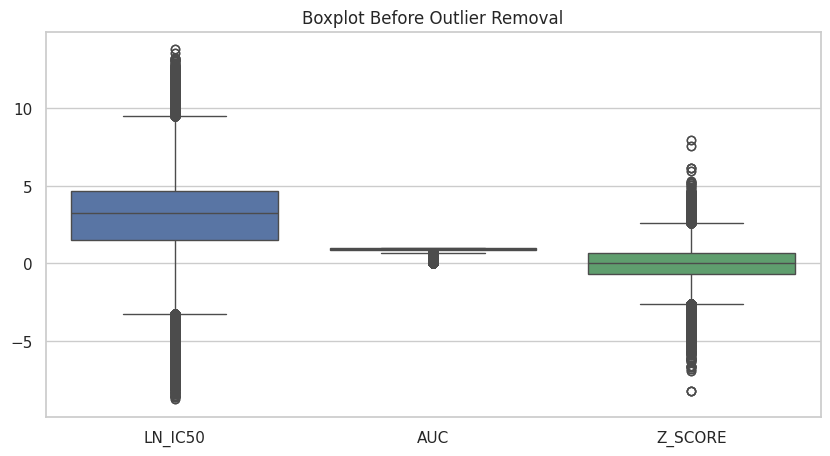

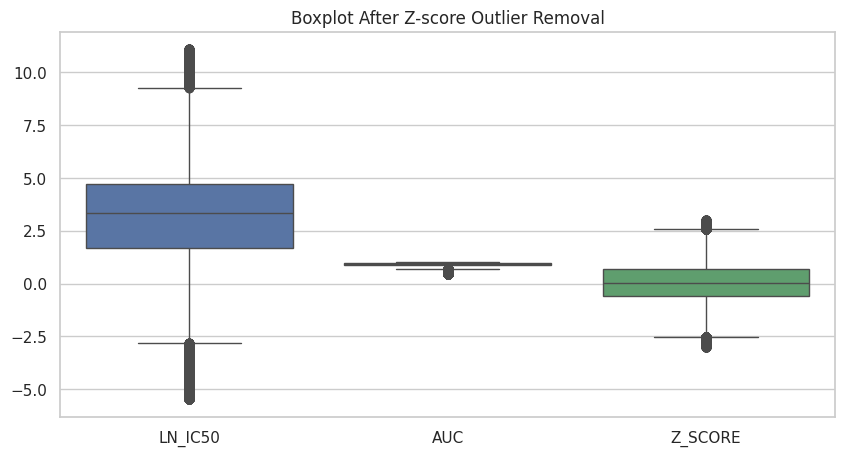

LN_IC50: 5184 outliers (1.07%)
AUC: 11654 outliers (2.41%)
Z_SCORE: 2788 outliers (0.58%)
Total rows: 484071
Outliers: 16838
Clean data: 467233


In [8]:
# Z-score calculation
from scipy.stats import zscore

num_cols = ["LN_IC50", "AUC", "Z_SCORE"]
df_num = df[num_cols].copy()

z_scores = np.abs(zscore(df_num))
z_df = pd.DataFrame(z_scores, columns=num_cols)

outlier_mask = (z_df > 3).any(axis=1)

df_outliers = df[outlier_mask]
df_clean = df[~outlier_mask]

plt.figure(figsize=(10,5))
sns.boxplot(data=df[num_cols])
plt.title("Boxplot Before Outlier Removal")
plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(data=df_clean[num_cols])
plt.title("Boxplot After Z-score Outlier Removal")
plt.show()

for col in num_cols:
    outliers_col = (z_df[col] > 3).sum()
    print(f"{col}: {outliers_col} outliers ({outliers_col/len(df)*100:.2f}%)")

print("Total rows:", df.shape[0])
print("Outliers:", df_outliers.shape[0])
print("Clean data:", df_clean.shape[0])

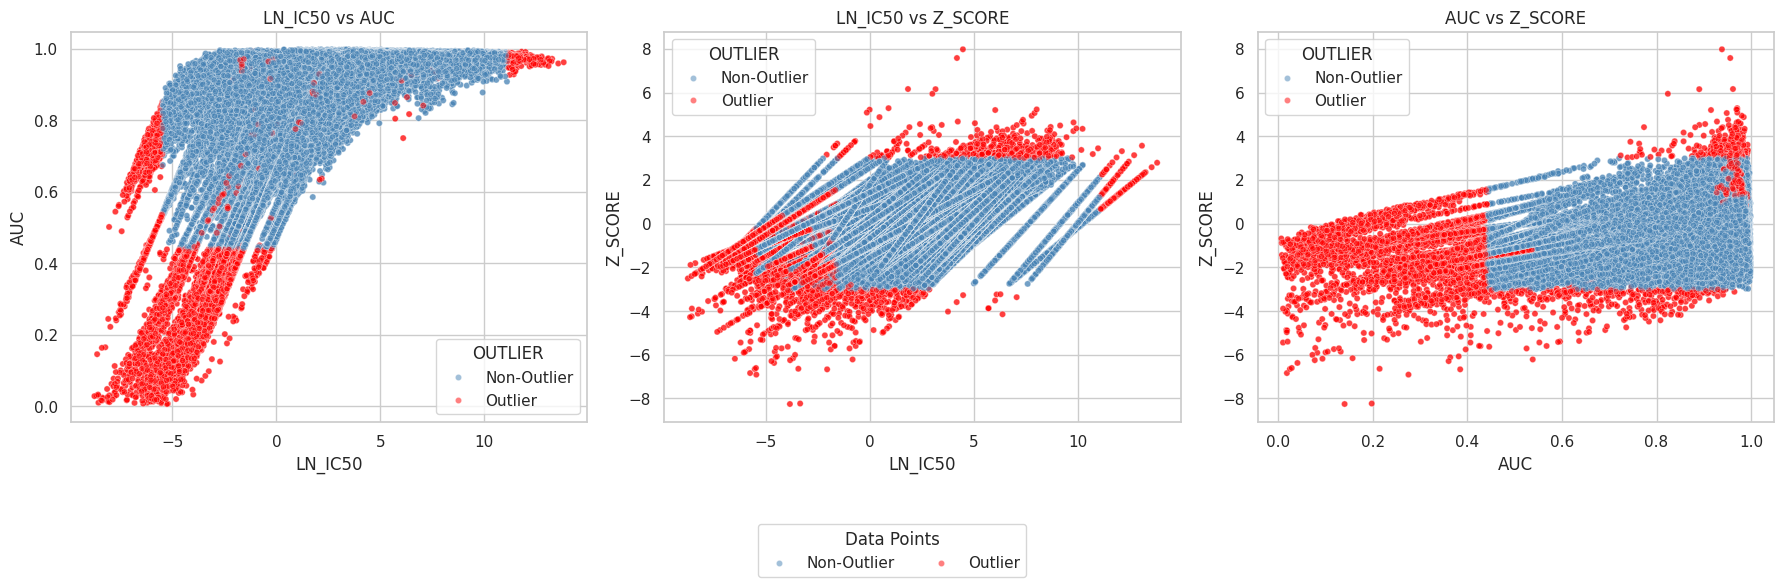

In [9]:
num_cols = ["LN_IC50", "AUC", "Z_SCORE"]

z_scores = np.abs(zscore(df[num_cols]))
z_df = pd.DataFrame(z_scores, columns=num_cols)

outlier_mask = (z_df > 3).any(axis=1)

df_plot = df.copy()
df_plot["OUTLIER"] = outlier_mask.map({True: "Outlier", False: "Non-Outlier"})

fig, axes = plt.subplots(1, 3, figsize=(18,5))

pairs = [
    ("LN_IC50", "AUC"),
    ("LN_IC50", "Z_SCORE"),
    ("AUC", "Z_SCORE")
]

for ax, (x, y) in zip(axes, pairs):
    sns.scatterplot(
        data=df_plot,
        x=x,
        y=y,
        hue="OUTLIER",
        palette={"Non-Outlier": "steelblue", "Outlier": "red"},
        alpha=0.5,
        s=20,
        ax=ax
    )
    ax.set_title(f"{x} vs {y}")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=2,
    title="Data Points"
)

plt.tight_layout()
plt.show()

- **Scatterplots comparing drug response metrics reveal that outliers (identified by Z-score > 3) are sparsely distributed and mainly occur at extreme values of LN_IC50 and Z_SCORE. This visualization supports the decision to treat or remove extreme observations prior to model training.**

/tmp/ipykernel_16/972114242.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")


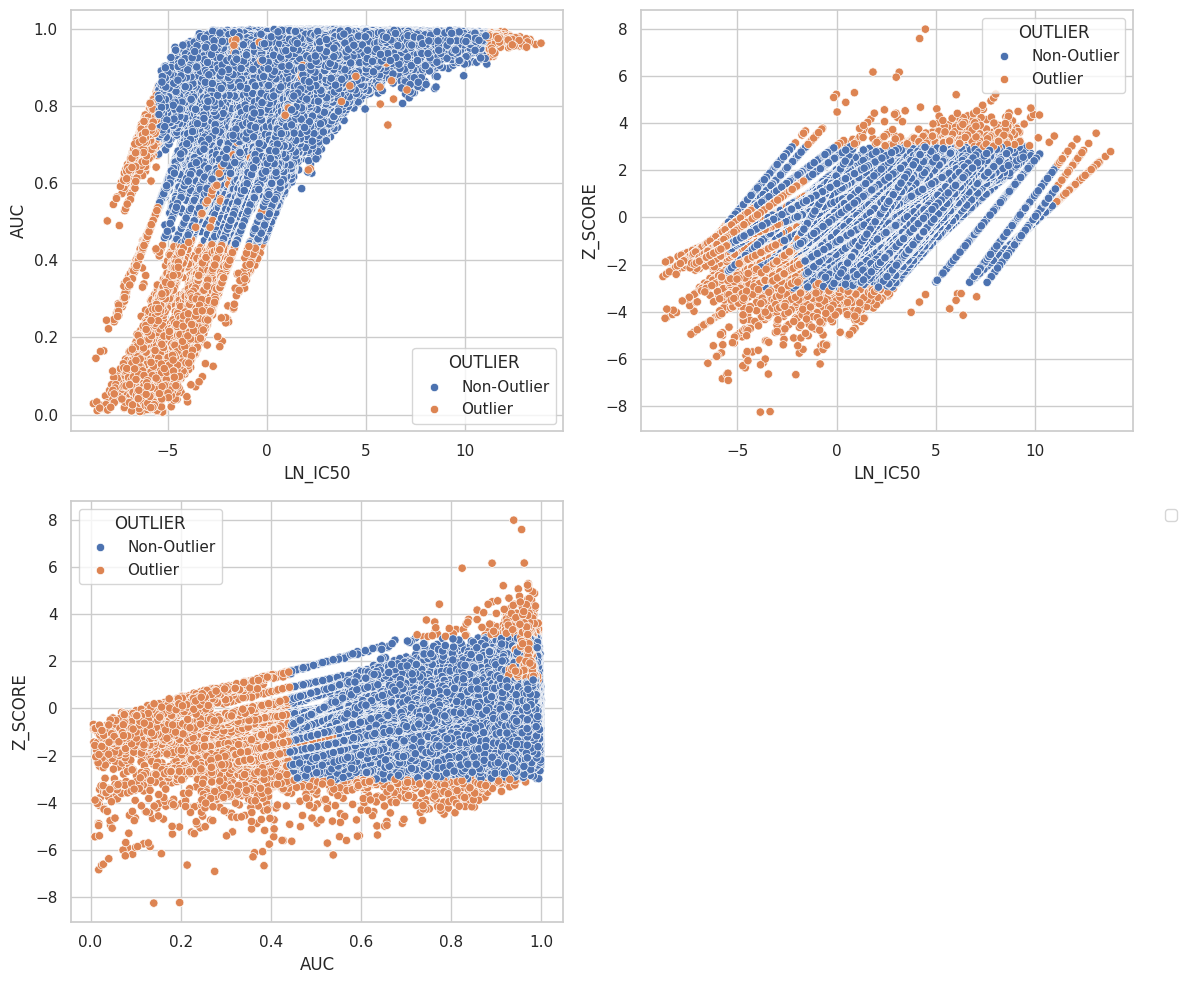

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12,10))

sns.scatterplot(data=df_plot, x="LN_IC50", y="AUC", hue="OUTLIER", ax=axes[0,0])
sns.scatterplot(data=df_plot, x="LN_IC50", y="Z_SCORE", hue="OUTLIER", ax=axes[0,1])
sns.scatterplot(data=df_plot, x="AUC", y="Z_SCORE", hue="OUTLIER", ax=axes[1,0])

axes[1,1].axis("off")

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

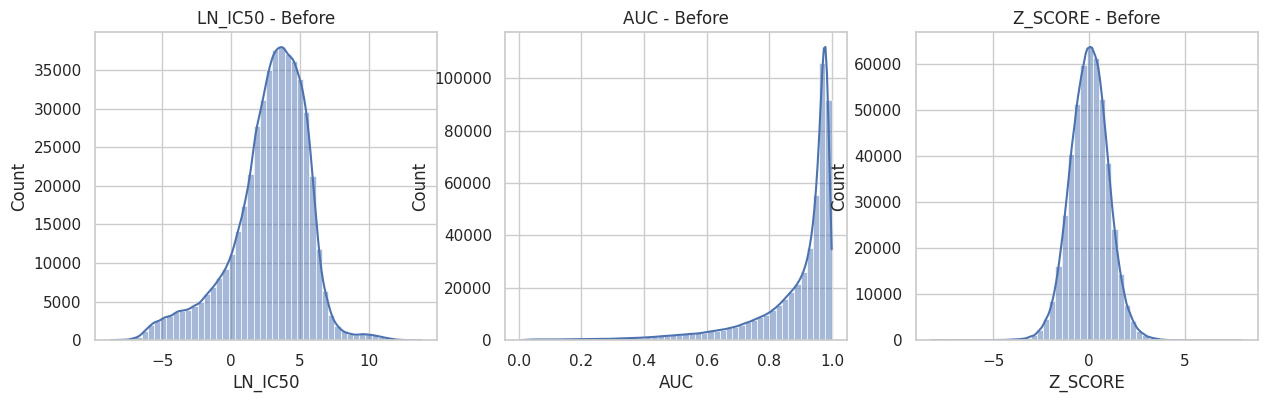

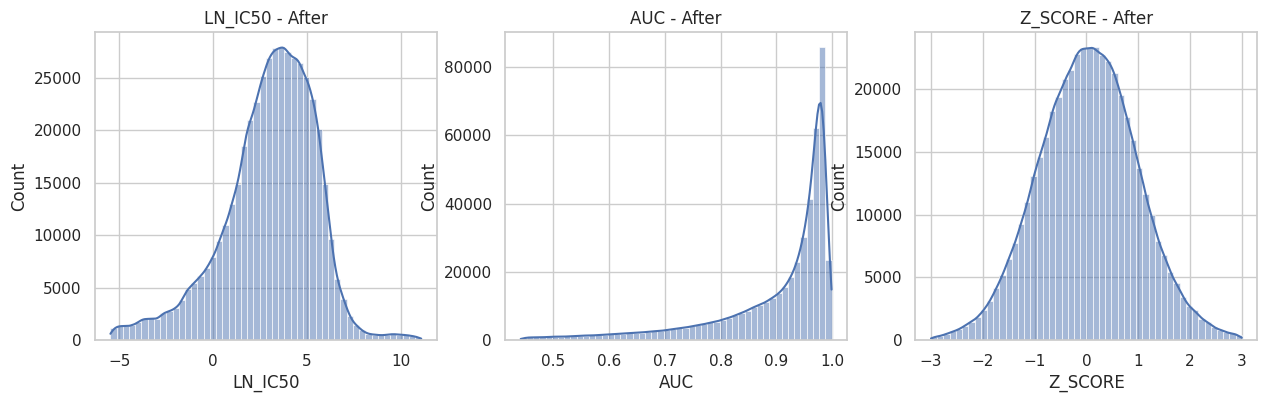

In [11]:
# Histograms before outlier removal
fig, axes = plt.subplots(1, 3, figsize=(15,4))

for i, col in enumerate(num_cols):
    sns.histplot(df[col], bins=50, ax=axes[i], kde=True)
    axes[i].set_title(f"{col} - Before")

plt.show()

# Histograms after outlier removal
fig, axes = plt.subplots(1, 3, figsize=(15,4))

for i, col in enumerate(num_cols):
    sns.histplot(df_clean[col], bins=50, ax=axes[i], kde=True)
    axes[i].set_title(f"{col} - After")

plt.show()

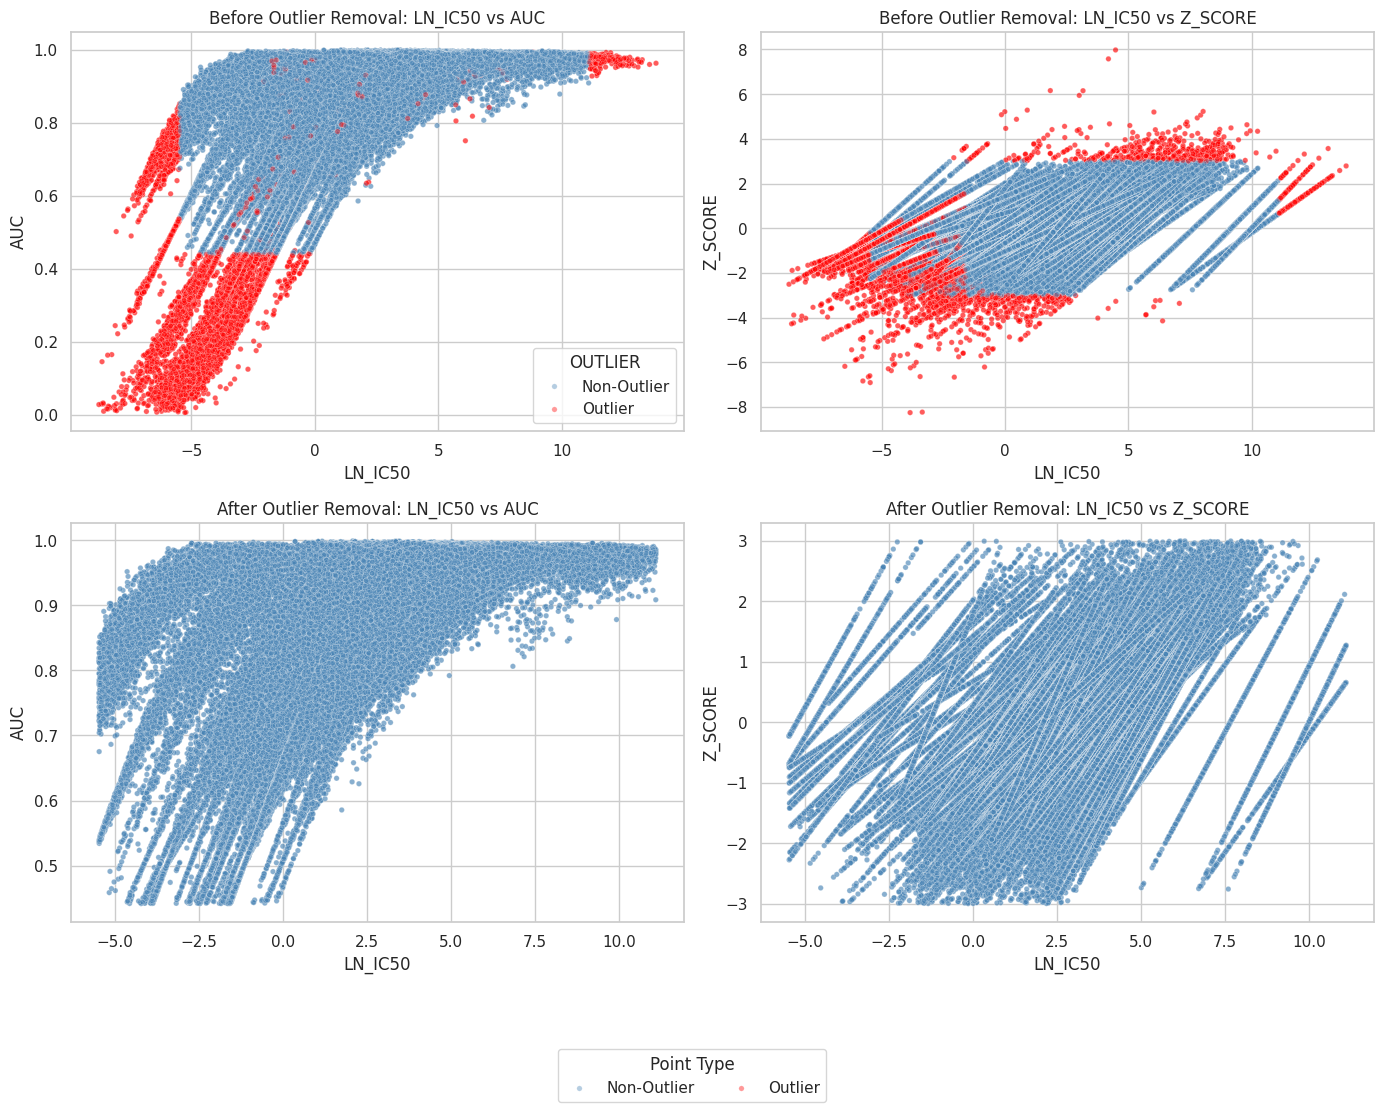

In [12]:
# Select numerical columns
num_cols = ["LN_IC50", "AUC", "Z_SCORE"]

z_scores = np.abs(zscore(df[num_cols]))
z_df = pd.DataFrame(z_scores, columns=num_cols)

outlier_mask = (z_df > 3).any(axis=1)

df_outliers = df[outlier_mask]
df_clean = df[~outlier_mask]

df_clean.to_csv(
    r"C:\Users\rafae.RAFAEL_NOTEBOOK\Downloads\Genomics of Drug Sensitivity in Cancer (GDSC)\output\gdsc_dataset_no_outliers.csv",
    index=False
)

fig, axes = plt.subplots(2, 2, figsize=(14,10))

palette = {"Non-Outlier": "steelblue", "Outlier": "red"}

sns.scatterplot(
    data=df_plot,
    x="LN_IC50",
    y="AUC",
    hue="OUTLIER",
    palette=palette,
    alpha=0.4,
    s=15,
    ax=axes[0,0]
)
axes[0,0].set_title("Before Outlier Removal: LN_IC50 vs AUC")

sns.scatterplot(
    data=df_plot,
    x="LN_IC50",
    y="Z_SCORE",
    hue="OUTLIER",
    palette=palette,
    alpha=0.4,
    s=15,
    ax=axes[0,1],
    legend=False
)
axes[0,1].set_title("Before Outlier Removal: LN_IC50 vs Z_SCORE")

sns.scatterplot(
    data=df_clean.assign(OUTLIER="Non-Outlier"),
    x="LN_IC50",
    y="AUC",
    hue="OUTLIER",
    palette=palette,
    alpha=0.4,
    s=15,
    ax=axes[1,0],
    legend=False
)
axes[1,0].set_title("After Outlier Removal: LN_IC50 vs AUC")

sns.scatterplot(
    data=df_clean.assign(OUTLIER="Non-Outlier"),
    x="LN_IC50",
    y="Z_SCORE",
    hue="OUTLIER",
    palette=palette,
    alpha=0.4,
    s=15,
    ax=axes[1,1],
    legend=False
)
axes[1,1].set_title("After Outlier Removal: LN_IC50 vs Z_SCORE")

handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title="Point Type",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=2
)

plt.tight_layout()
plt.show()

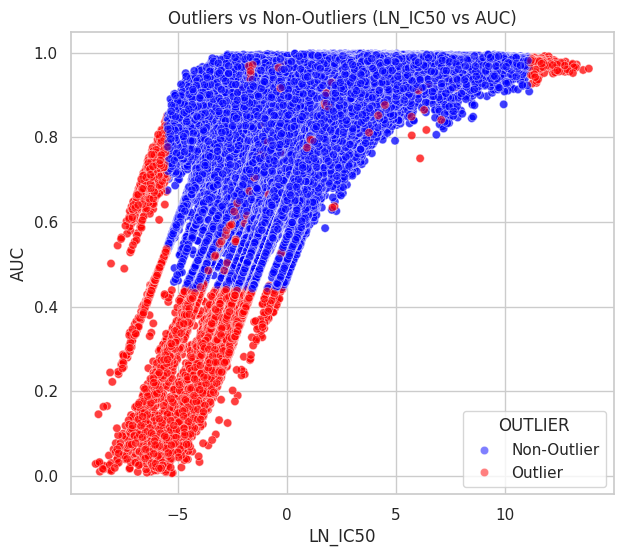

Original dataset: (484071, 15)
Outliers removed: (16838, 15)
Clean dataset: (467233, 15)
Percentage of outliers removed: 3.48%


In [13]:
df_plot = df.copy()
df_plot["OUTLIER"] = outlier_mask.map({True: "Outlier", False: "Non-Outlier"})

plt.figure(figsize=(7,6))
sns.scatterplot(
    data=df_plot,
    x="LN_IC50",
    y="AUC",
    hue="OUTLIER",
    palette={"Outlier": "red", "Non-Outlier": "blue"},
    alpha=0.5
)
plt.title("Outliers vs Non-Outliers (LN_IC50 vs AUC)")
plt.show()

print("Original dataset:", df.shape)
print("Outliers removed:", df_outliers.shape)
print("Clean dataset:", df_clean.shape)

percent_removed = len(df_outliers) / len(df) * 100
print(f"Percentage of outliers removed: {percent_removed:.2f}%")

- **Scatterplots before and after outlier removal show a significant reduction of extreme values in drug response metrics (LN_IC50, AUC, Z_SCORE), leading to more compact and interpretable data distributions for subsequent machine learning modeling.**

In [14]:
df_wins = df.copy()

for col in num_cols:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df_wins[col] = df[col].clip(lower, upper)

- **Outliers were detected using the Z-score method on numerical drug response variables (LN_IC50, AUC, and Z_SCORE). Samples with an absolute Z-score greater than 3 in any variable were removed in order to reduce the influence of extreme experimental values and improve model stability.**

# **Part 5 - Feature engineering**

In [15]:
cat_cols = df_clean.select_dtypes(include=["object", "bool"]).columns
cat_cols

Index(['CELL_LINE_NAME', 'TCGA_DESC', 'DRUG_NAME', 'TARGET', 'TARGET_PATHWAY',
       'SITE', 'HISTOLOGY', 'GDSC_TISSUE_DESCRIPTOR_1',
       'GDSC_TISSUE_DESCRIPTOR_2', 'CANCER_TYPE_MATCHING_TCGA_LABEL'],
      dtype='object')

In [16]:
le = LabelEncoder()

for col in cat_cols:
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))

df_clean.dtypes

le

/tmp/ipykernel_16/2737642983.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean[col] = le.fit_transform(df_clean[col].astype(str))
/tmp/ipykernel_16/2737642983.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean[col] = le.fit_transform(df_clean[col].astype(str))
/tmp/ipykernel_16/2737642983.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://

LabelEncoder()

In [17]:
# Categorical columns
cat_cols = [
    "CELL_LINE_NAME",
    "TCGA_DESC",
    "DRUG_NAME",
    "TARGET",
    "TARGET_PATHWAY",
    "SITE",
    "HISTOLOGY",
    "GDSC_TISSUE_DESCRIPTOR_1",
    "GDSC_TISSUE_DESCRIPTOR_2",
    "CANCER_TYPE_MATCHING_TCGA_LABEL"
]

df_fe = df.copy()

for col in cat_cols:
    le = LabelEncoder()
    df_fe[col] = df_fe[col].astype(str).fillna("Unknown")
    df_fe[col + "_ENC"] = le.fit_transform(df_fe[col])

le

LabelEncoder()

In [18]:
df_fe

,COSMIC_ID,CELL_LINE_NAME,TCGA_DESC,DRUG_ID,DRUG_NAME,LN_IC50,AUC,Z_SCORE,TARGET,TARGET_PATHWAY,...,CELL_LINE_NAME_ENC,TCGA_DESC_ENC,DRUG_NAME_ENC,TARGET_ENC,TARGET_PATHWAY_ENC,SITE_ENC,HISTOLOGY_ENC,GDSC_TISSUE_DESCRIPTOR_1_ENC,GDSC_TISSUE_DESCRIPTOR_2_ENC,CANCER_TYPE_MATCHING_TCGA_LABEL_ENC
0,683667,PFSK-1,MB,1003,Camptothecin,-1.463887,0.930220,0.433123,TOP1,DNA replication,...,736,18,73,165,7,6,24,12,37,18
1,684057,ES5,UNCLASSIFIED,1003,Camptothecin,-3.360586,0.791072,-0.599569,TOP1,DNA replication,...,199,31,73,165,7,4,0,1,18,31
2,684059,ES7,UNCLASSIFIED,1003,Camptothecin,-5.044940,0.592660,-1.516647,TOP1,DNA replication,...,201,31,73,165,7,4,0,1,18,31
3,684062,EW-11,UNCLASSIFIED,1003,Camptothecin,-3.741991,0.734047,-0.807232,TOP1,DNA replication,...,209,31,73,165,7,4,0,1,18,31
4,684072,SK-ES-1,UNCLASSIFIED,1003,Camptothecin,-5.142961,0.582439,-1.570016,TOP1,DNA replication,...,806,31,73,165,7,4,0,1,18,31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
484066,1659928,SNU-175,COREAD,2499,N-acetyl cysteine,10.127082,0.976746,0.156872,Metabolism,Metabolism,...,841,6,172,112,14,11,5,5,25,6
484067,1660034,SNU-407,COREAD,2499,N-acetyl cysteine,8.576377,0.913378,-1.626959,Metabolism,Metabolism,...,845,6,172,112,14,11,5,5,25,6
484068,1660035,SNU-61,COREAD,2499,N-acetyl cysteine,10.519636,0.975001,0.608442,Metabolism,Metabolism,...,849,6,172,112,14,11,5,5,25,6
484069,1674021,SNU-C5,COREAD,2499,N-acetyl cysteine,10.694579,0.969969,0.809684,Metabolism,Metabolism,...,853,6,172,112,14,11,5,5,25,6


# Part 6 - Division x and y

Columns used for correlation:
['DRUG_ID', 'LN_IC50', 'AUC', 'Z_SCORE', 'CELL_LINE_NAME_ENC', 'TCGA_DESC_ENC', 'DRUG_NAME_ENC', 'TARGET_ENC', 'TARGET_PATHWAY_ENC', 'SITE_ENC', 'HISTOLOGY_ENC', 'GDSC_TISSUE_DESCRIPTOR_1_ENC', 'GDSC_TISSUE_DESCRIPTOR_2_ENC', 'CANCER_TYPE_MATCHING_TCGA_LABEL_ENC']


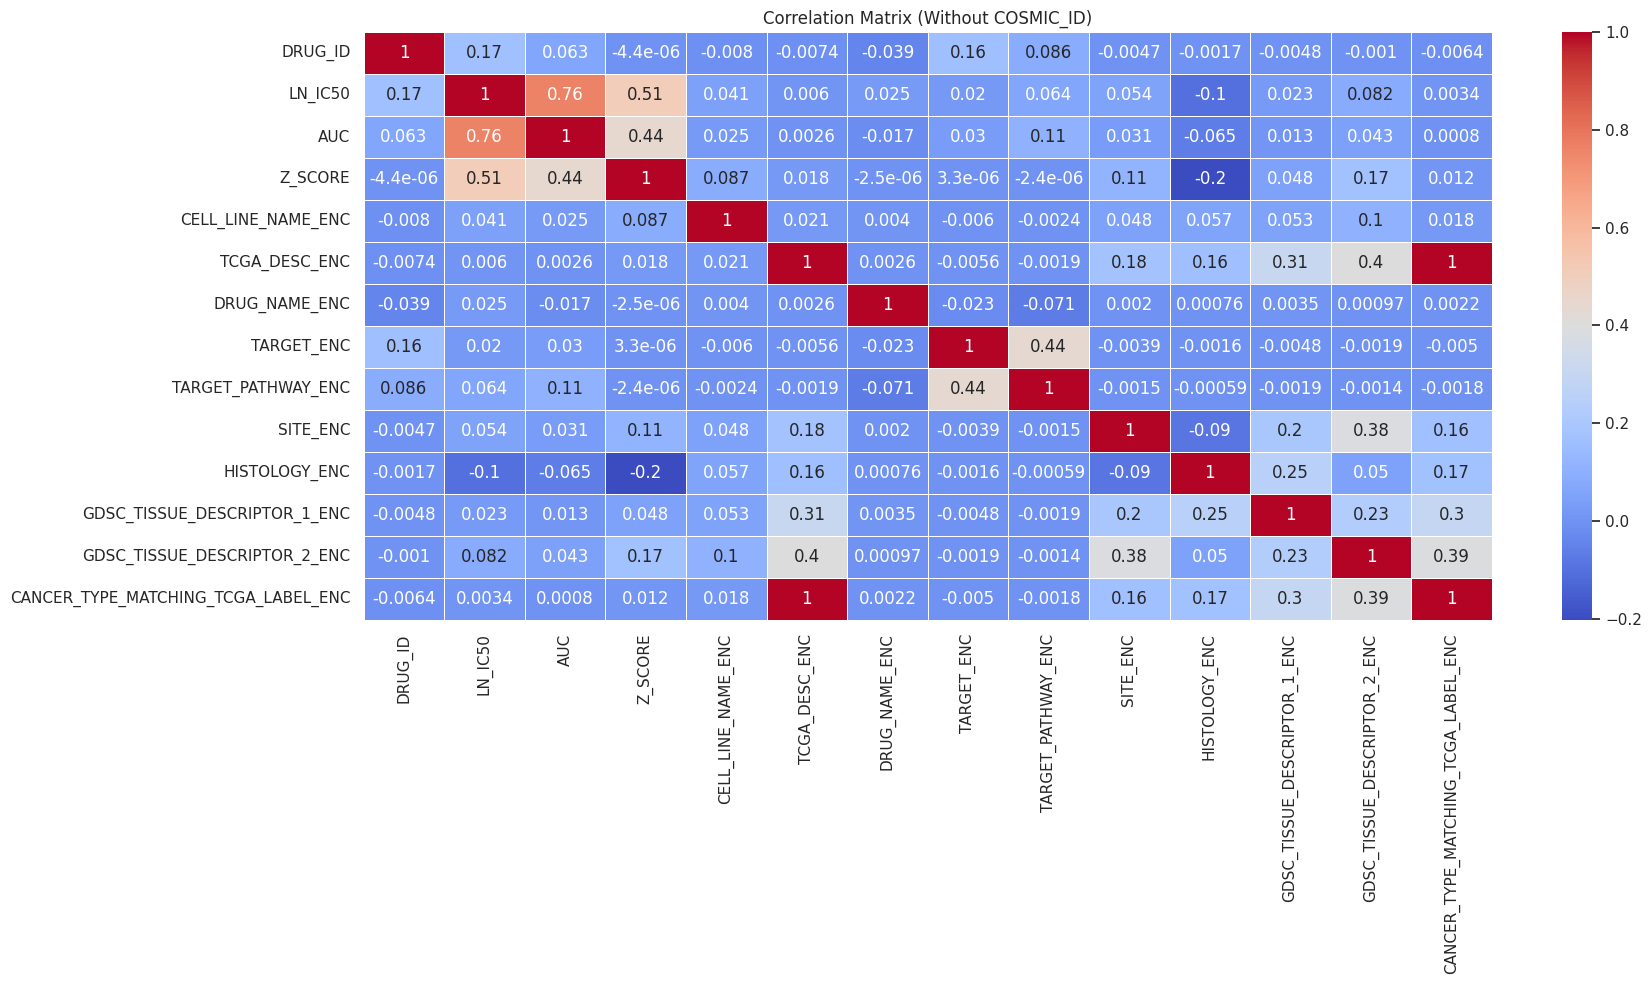

In [19]:
df_corr = df_fe.select_dtypes(include=["int64", "float64"])

if "COSMIC_ID" in df_corr.columns:
    df_corr = df_corr.drop(columns=["COSMIC_ID"])

print("Columns used for correlation:")
print(df_corr.columns.tolist())

corr_matrix = df_corr.corr()

plt.figure(figsize=(18,10))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=True,
    linewidths=0.5
)

plt.title("Correlation Matrix (Without COSMIC_ID)")
plt.tight_layout()
plt.show()


**Correlation Analysis**

**Strong Correlations (≥ 0.5)**

- LN_IC50 ↔ AUC = 0.76 (strong positive)
- LN_IC50 ↔ Z_SCORE = 0.51 (moderate/strong)

**Moderate Correlations (≈ 0.3 – 0.49)**

- **TARGET_ENC ↔ TARGET_PATHWAY_ENC = 0.44**

- **TCGA_DESC_ENC ↔ GDSC_TISSUE_DESCRIPTOR_2_ENC = 0.40**

- **GDSC_TISSUE_DESCRIPTOR_2_ENC ↔ CANCER_TYPE_MATCHING_TCGA_LABEL_ENC = 0.39**

- **SITE_ENC ↔ GDSC_TISSUE_DESCRIPTOR_2_ENC = 0.38**

- **TCGA_DESC_ENC ↔ GDSC_TISSUE_DESCRIPTOR_1_ENC = 0.31**

- **DSC_TISSUE_DESCRIPTOR_1_ENC ↔ CANCER_TYPE_MATCHING_TCGA_LABEL_ENC = 0.30**

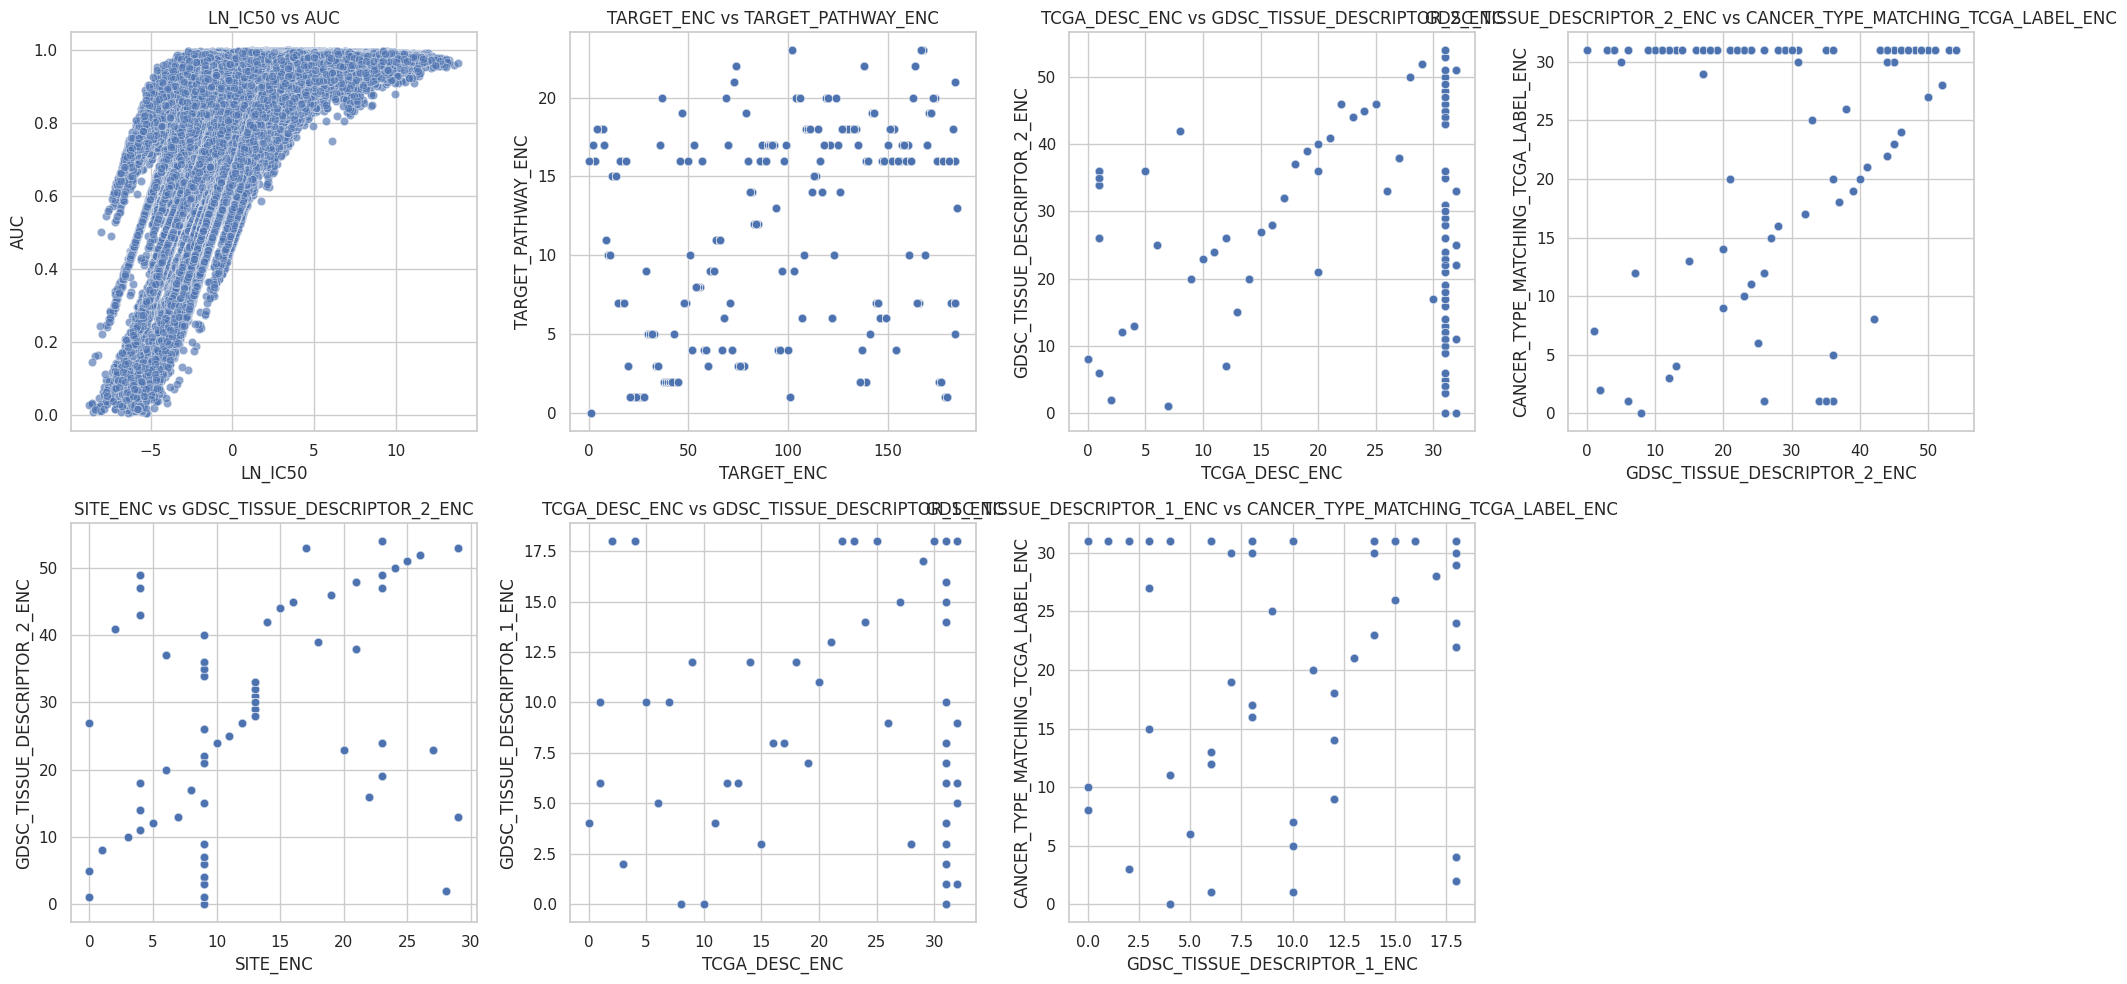

In [20]:
# Positive correlation pairs
pairs = [
("LN_IC50","AUC"),
("TARGET_ENC","TARGET_PATHWAY_ENC"),
("TCGA_DESC_ENC","GDSC_TISSUE_DESCRIPTOR_2_ENC"),
("GDSC_TISSUE_DESCRIPTOR_2_ENC","CANCER_TYPE_MATCHING_TCGA_LABEL_ENC"),
("SITE_ENC","GDSC_TISSUE_DESCRIPTOR_2_ENC"),
("TCGA_DESC_ENC","GDSC_TISSUE_DESCRIPTOR_1_ENC"),
("GDSC_TISSUE_DESCRIPTOR_1_ENC","CANCER_TYPE_MATCHING_TCGA_LABEL_ENC")
]

fig, axes = plt.subplots(2, 4, figsize=(20,10))
axes = axes.flatten()

for ax, (x_col, y_col) in zip(axes, pairs):
    
    sns.scatterplot(
        data=df_fe,
        x=x_col,
        y=y_col,
        alpha=0.4,
        ax=ax
    )
    
    ax.set_title(f"{x_col} vs {y_col}")
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)

for i in range(len(pairs), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [21]:
# Final Regression Features

feature_cols = [c + "_ENC" for c in cat_cols] + ["AUC"]

MODEL_FEATURES = [
    "AUC",
    "DRUG_NAME_ENC",
    "TARGET_ENC",
    "TARGET_PATHWAY_ENC",
    "TCGA_DESC_ENC",
    "GDSC_TISSUE_DESCRIPTOR_2_ENC",
    "CANCER_TYPE_MATCHING_TCGA_LABEL_ENC",
    "SITE_ENC",
    "GDSC_TISSUE_DESCRIPTOR_1_ENC"
]

X = df_fe[MODEL_FEATURES]
y = df_fe["LN_IC50"]

print("Features:")
print(MODEL_FEATURES)

print("X shape:", X.shape)
print("y shape:", y.shape)

Features:
['AUC', 'DRUG_NAME_ENC', 'TARGET_ENC', 'TARGET_PATHWAY_ENC', 'TCGA_DESC_ENC', 'GDSC_TISSUE_DESCRIPTOR_2_ENC', 'CANCER_TYPE_MATCHING_TCGA_LABEL_ENC', 'SITE_ENC', 'GDSC_TISSUE_DESCRIPTOR_1_ENC']
X shape: (484071, 9)
y shape: (484071,)


In [22]:
print(X.columns.tolist())
print("Contains Z_SCORE?", "Z_SCORE" in X.columns)
print("Contains AUC?", "AUC" in X.columns)

['AUC', 'DRUG_NAME_ENC', 'TARGET_ENC', 'TARGET_PATHWAY_ENC', 'TCGA_DESC_ENC', 'GDSC_TISSUE_DESCRIPTOR_2_ENC', 'CANCER_TYPE_MATCHING_TCGA_LABEL_ENC', 'SITE_ENC', 'GDSC_TISSUE_DESCRIPTOR_1_ENC']
Contains Z_SCORE? False
Contains AUC? True


# Part 7 - Train / Test split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Part 8 - Standardization

In [24]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

scaler

StandardScaler()

# **Section B) Machine learning model - Linear regression**

# Part 9 - Machine Learning Linear Regression simpls Model 

In [25]:
# Model Linear Regression
reg = LinearRegression()
reg.fit(X_train_scaled, y_train)

LinearRegression()

In [26]:
y_pred = reg.predict(X_test_scaled)

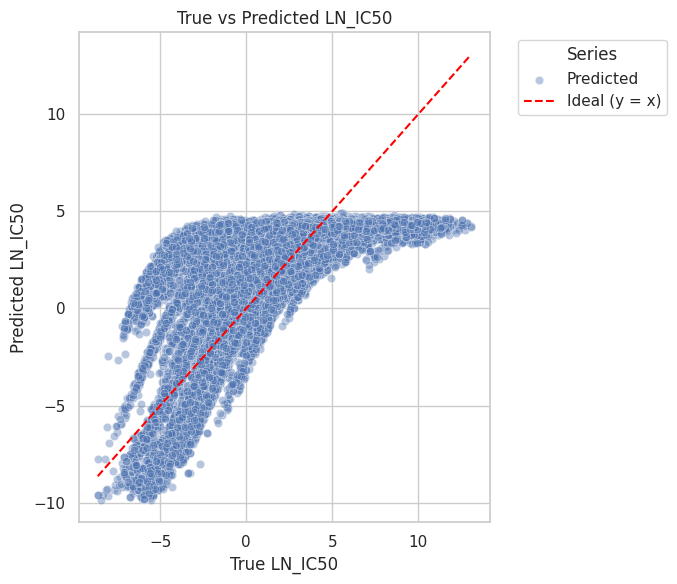

In [27]:
plt.figure(figsize=(7,6))

ax = sns.scatterplot(x=y_test, y=y_pred, alpha=0.4, label="Predicted")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--",
    label="Ideal (y = x)"
)

plt.xlabel("True LN_IC50")
plt.ylabel("Predicted LN_IC50")
plt.title("True vs Predicted LN_IC50")

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    title="Series"
)

plt.tight_layout()
plt.show()

In [28]:
residuals = y_test - y_pred

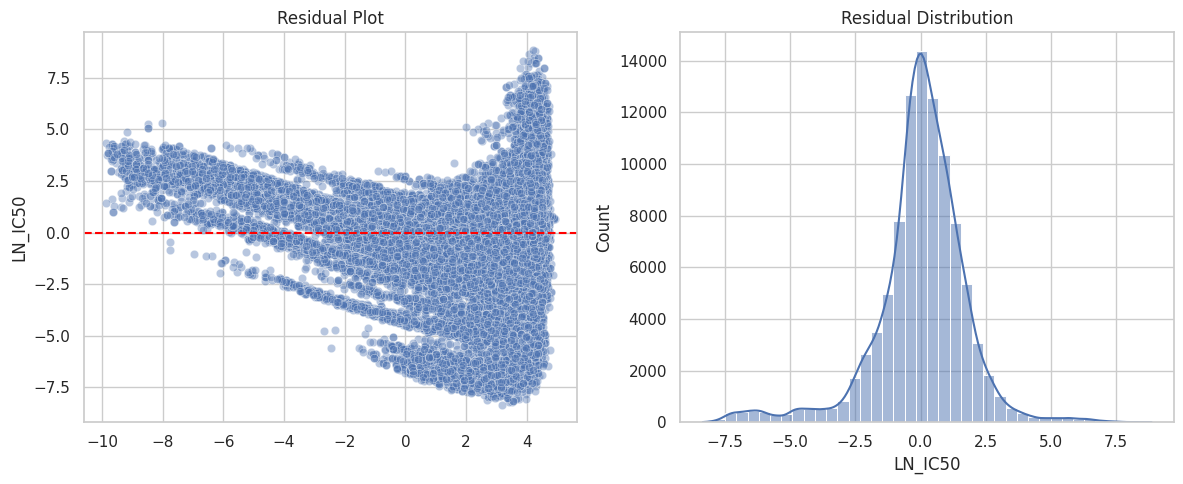

In [29]:
fig, axes = plt.subplots(1,2, figsize=(12,5))

sns.scatterplot(x=y_pred, y=residuals, alpha=0.4, ax=axes[0])
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_title("Residual Plot")

sns.histplot(residuals, bins=40, kde=True, ax=axes[1])
axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.show()


In [30]:
# Model evaluation
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R²:", r2)

RMSE: 1.7809403744346435
R²: 0.5851182274621806


# **Part 10 - Machine learning models, linear regression, others**

In [31]:
%%time

# Regression models
models = {
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.001),
    "ElasticNet": ElasticNet(alpha=0.001, l1_ratio=0.5),
    
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
    
    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    ),
    
    "LightGBM": LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        random_state=42
    ),
    
    "CatBoost": CatBoostRegressor(
        iterations=300,
        learning_rate=0.05,
        depth=6,
        verbose=0,
        random_state=42
    )
}

trained_models = {}
results = []

# Train regression models
for name, model in tqdm(models.items(), desc="Training regression models"):
    
    if name in ["Ridge", "Lasso", "ElasticNet"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    trained_models[name] = model
    
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        "Model": name,
        "RMSE": rmse,
        "R2": r2
    })
    
    tqdm.write(f"{name} -> RMSE: {rmse:.3f} | R2: {r2:.3f}")

results_df = pd.DataFrame(results).sort_values("RMSE")
results_df

Training regression models:  29%|██▊       | 2/7 [00:00<00:00, 10.42it/s]

Ridge -> RMSE: 1.781 | R2: 0.585
Lasso -> RMSE: 1.781 | R2: 0.585


Training regression models:  29%|██▊       | 2/7 [00:02<00:00, 10.42it/s]

ElasticNet -> RMSE: 1.781 | R2: 0.585


Training regression models:  57%|█████▋    | 4/7 [01:11<01:02, 20.96s/it]

...

Training regression models:  86%|████████▌ | 6/7 [01:21<00:13, 13.09s/it]

LightGBM -> RMSE: 0.674 | R2: 0.941


Training regression models: 100%|██████████| 7/7 [01:30<00:00, 12.93s/it]

CatBoost -> RMSE: 0.858 | R2: 0.904
CPU times: user 2min 18s, sys: 2.23 s, total: 2min 21s
Wall time: 1min 30s


,Model,RMSE,R2
5,LightGBM,0.673604,0.940648
4,XGBoost,0.691484,0.937455
6,CatBoost,0.857645,0.903785
3,GradientBoosting,1.148448,0.827477
0,Ridge,1.780940,0.585118
2,ElasticNet,1.781010,0.585086
1,Lasso,1.781023,0.585080


- Multiple regression models were evaluated to predict LN_IC50 values. Ensemble-based gradient boosting models (LightGBM, XGBoost, and CatBoost) significantly outperformed linear and regularized regression models, achieving R² values above 0.93. These results indicate strong nonlinear relationships between molecular pathways, cancer types, and drug response.

Plotting Feature Importance:   0%|          | 0/7 [00:00<?, ?it/s]

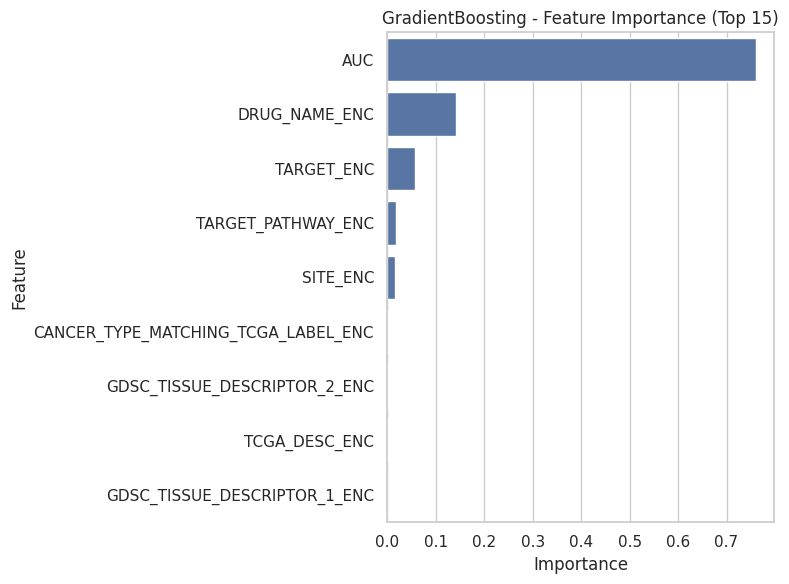

Plotting Feature Importance:  57%|█████▋    | 4/7 [00:00<00:00, 20.42it/s]

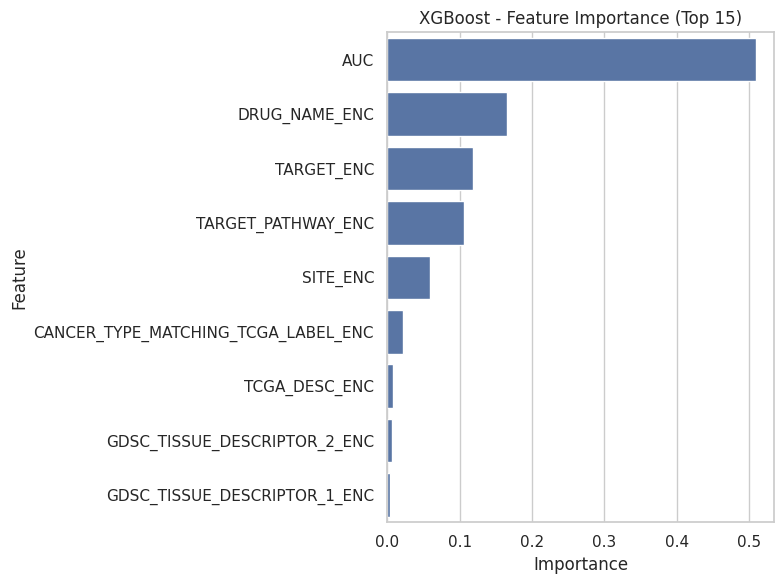

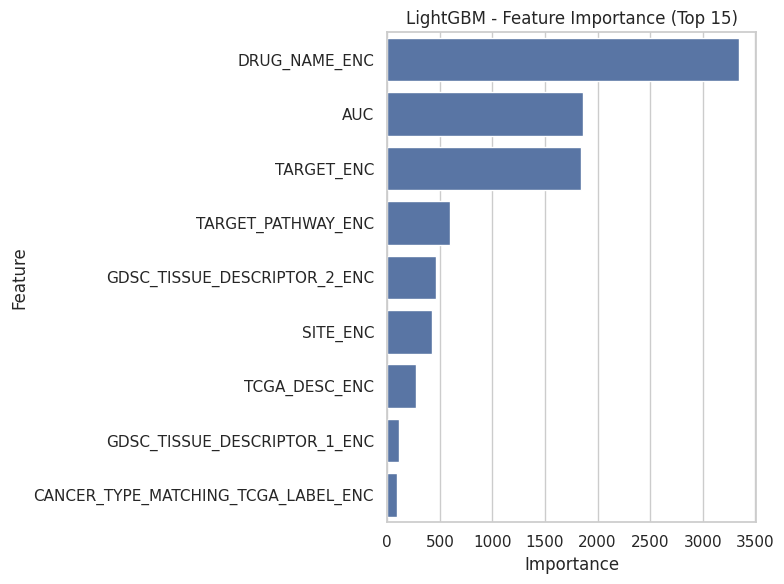

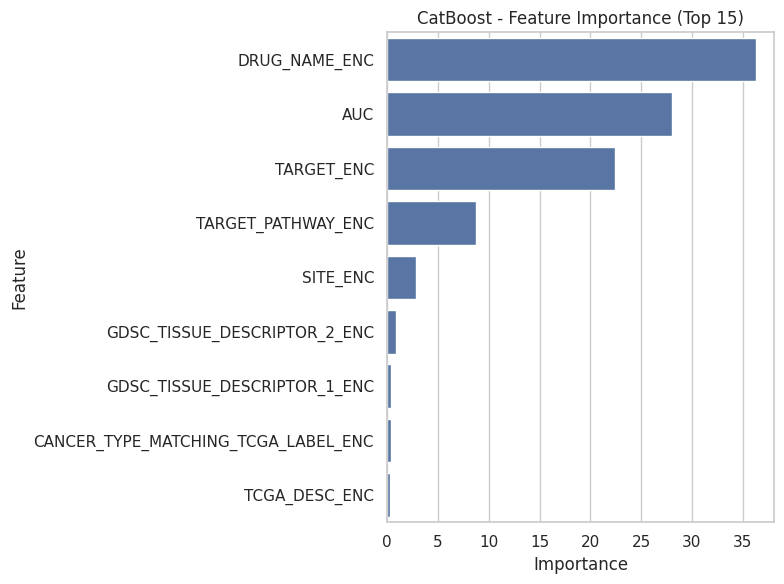

Plotting Feature Importance: 100%|██████████| 7/7 [00:00<00:00,  9.04it/s]


In [32]:
feature_cols = X_train.columns.tolist()

for name, model in tqdm(trained_models.items(), desc="Plotting Feature Importance"):
    
    if name in ["GradientBoosting", "XGBoost", "LightGBM", "CatBoost"]:
        
        if name == "CatBoost":
            importance = model.get_feature_importance()
        else:
            importance = model.feature_importances_
        
        imp_df = pd.DataFrame({
            "Feature": feature_cols,
            "Importance": importance
        }).sort_values("Importance", ascending=False).head(15)
        
        plt.figure(figsize=(8,6))
        sns.barplot(data=imp_df, x="Importance", y="Feature")
        plt.title(f"{name} - Feature Importance (Top 15)")
        plt.tight_layout()
        plt.show()

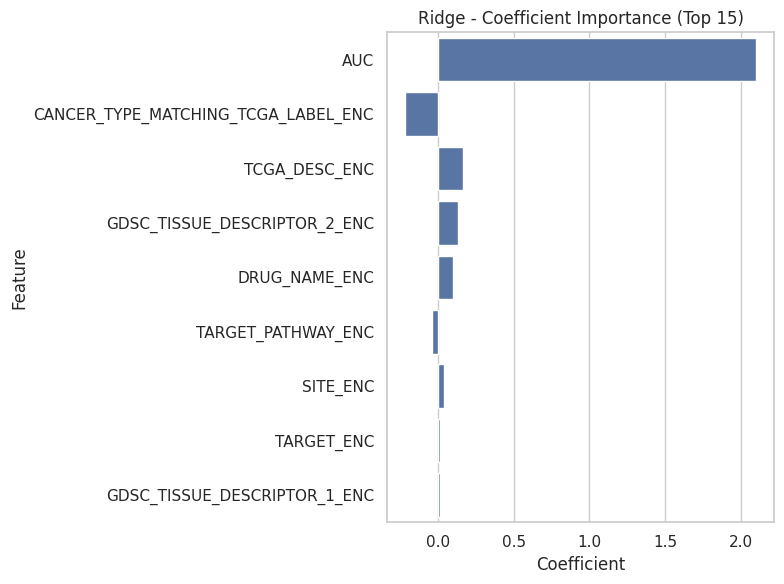

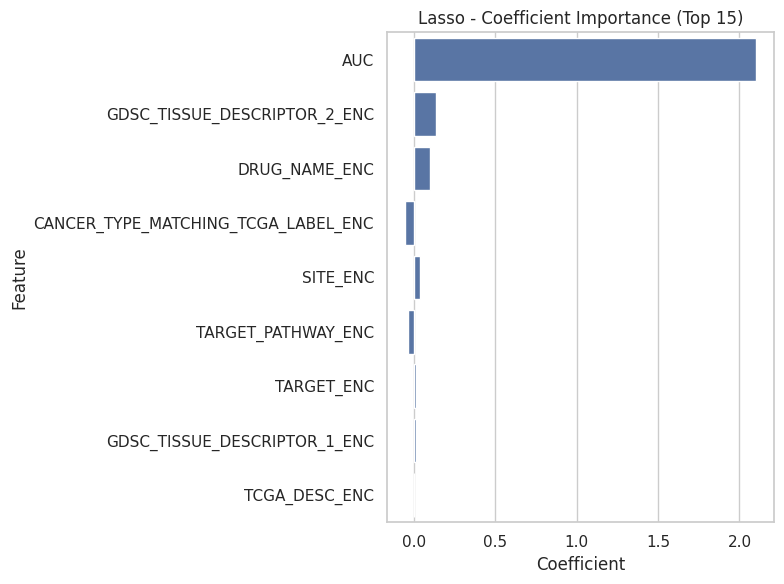

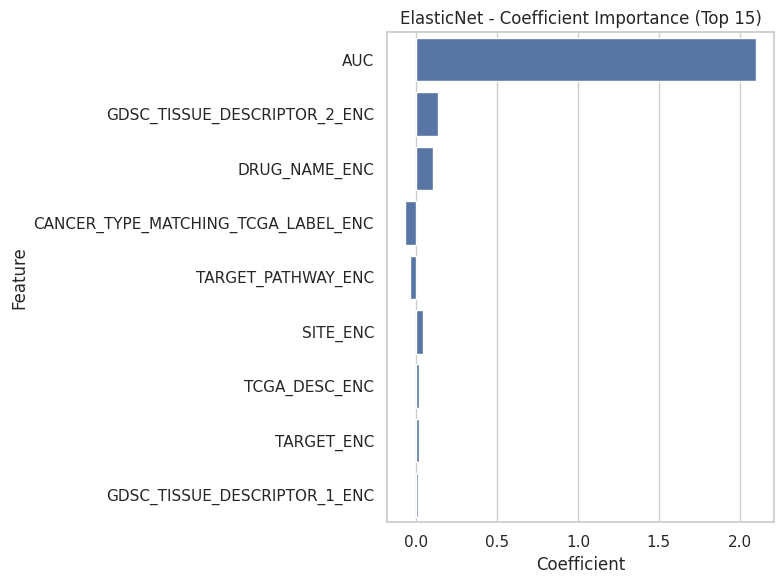

In [33]:
for name in ["Ridge", "Lasso", "ElasticNet"]:
    model = trained_models[name]
    
    coef_df = pd.DataFrame({
        "Feature": feature_cols,
        "Coefficient": model.coef_
    }).sort_values("Coefficient", key=abs, ascending=False).head(15)
    
    plt.figure(figsize=(8,6))
    sns.barplot(data=coef_df, x="Coefficient", y="Feature")
    plt.title(f"{name} - Coefficient Importance (Top 15)")
    plt.tight_layout()
    plt.show()


Plotting residuals:   0%|          | 0/7 [00:00<?, ?it/s]

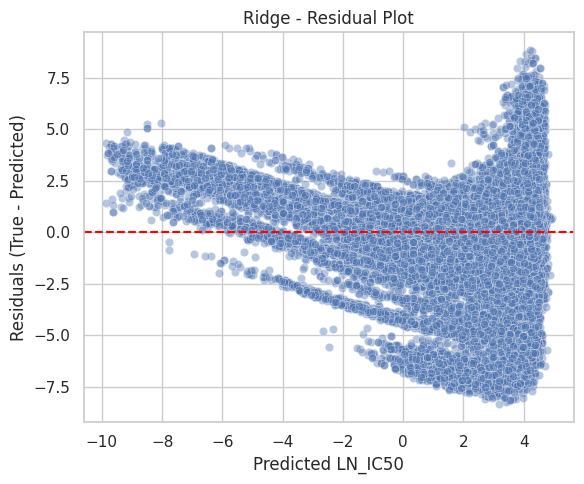

Plotting residuals:  14%|█▍        | 1/7 [00:00<00:03,  1.91it/s]

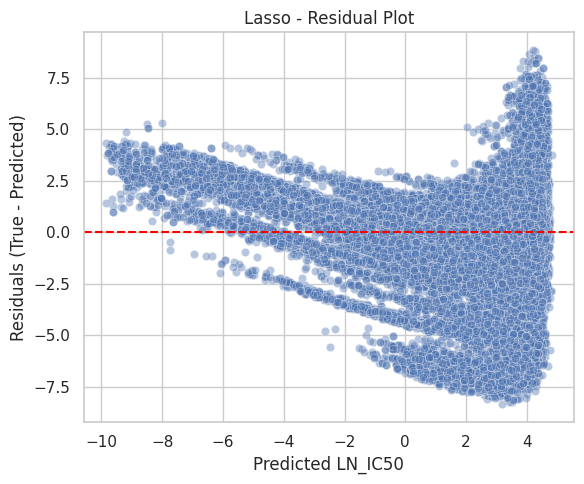

Plotting residuals:  29%|██▊       | 2/7 [00:01<00:02,  1.95it/s]

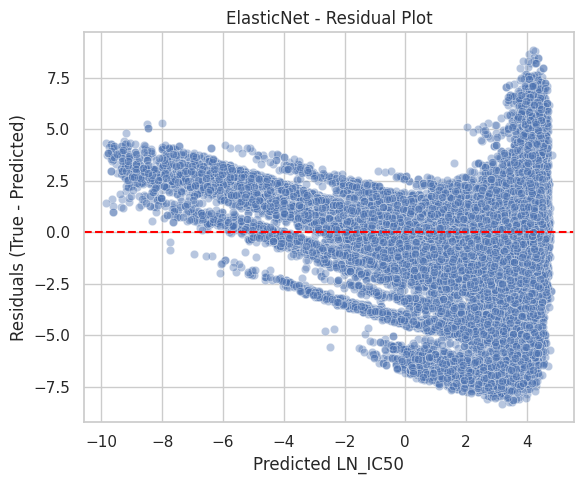

Plotting residuals:  43%|████▎     | 3/7 [00:01<00:02,  1.94it/s]

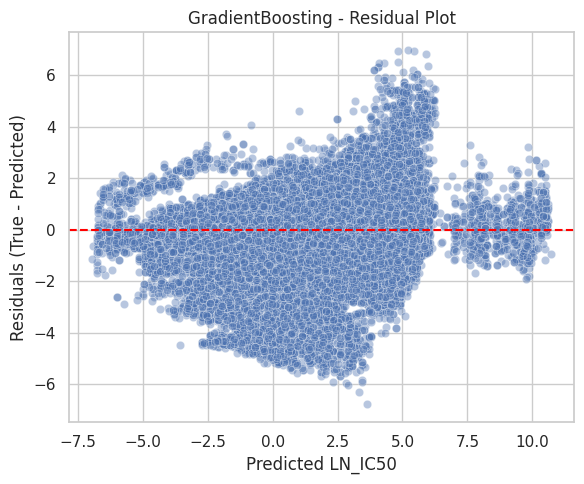

Plotting residuals:  57%|█████▋    | 4/7 [00:02<00:01,  1.73it/s]

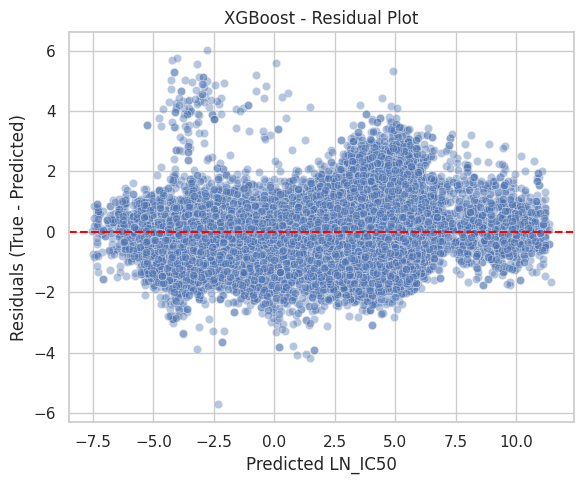

Plotting residuals:  71%|███████▏  | 5/7 [00:03<00:01,  1.43it/s]

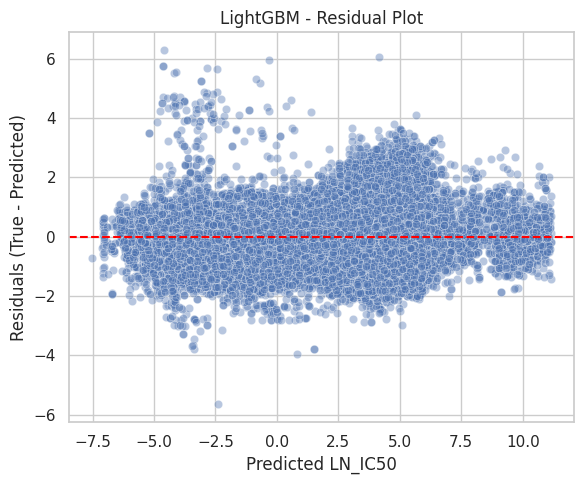

Plotting residuals:  86%|████████▌ | 6/7 [00:04<00:01,  1.06s/it]

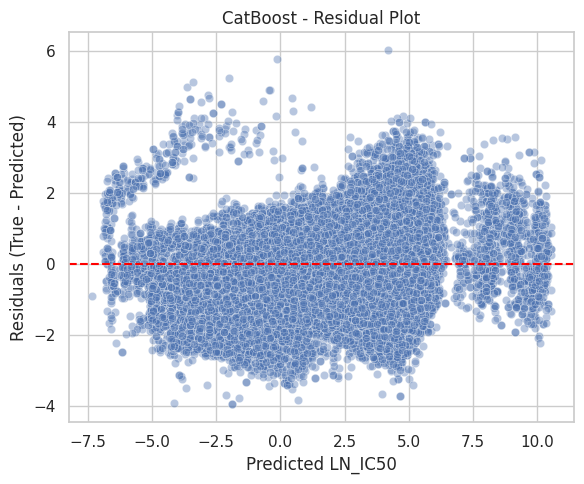

Residual distribution:   0%|          | 0/7 [00:00<?, ?it/s]

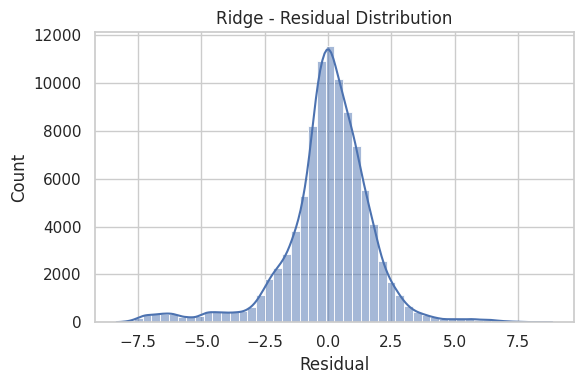

Residual distribution:  14%|█▍        | 1/7 [00:00<00:04,  1.27it/s]

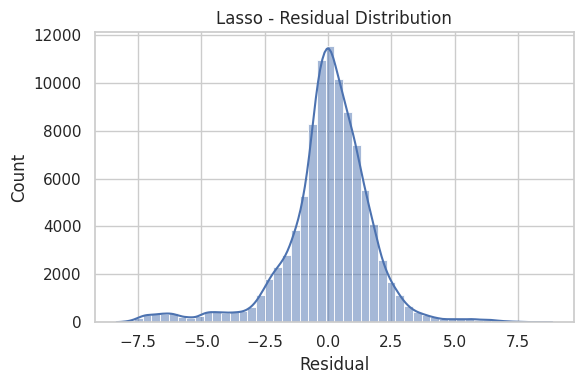

Residual distribution:  29%|██▊       | 2/7 [00:01<00:03,  1.25it/s]

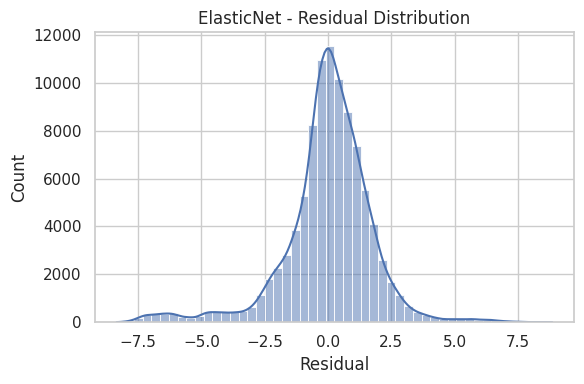

Residual distribution:  43%|████▎     | 3/7 [00:02<00:03,  1.25it/s]

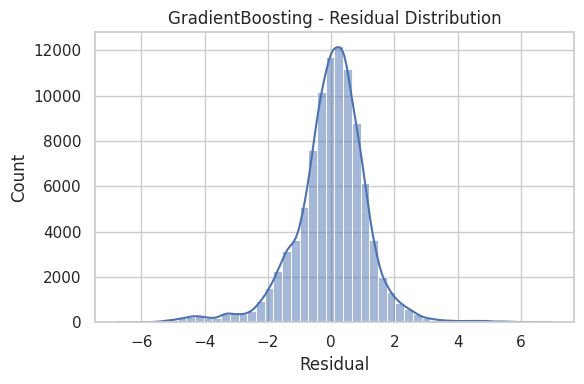

Residual distribution:  57%|█████▋    | 4/7 [00:03<00:02,  1.18it/s]

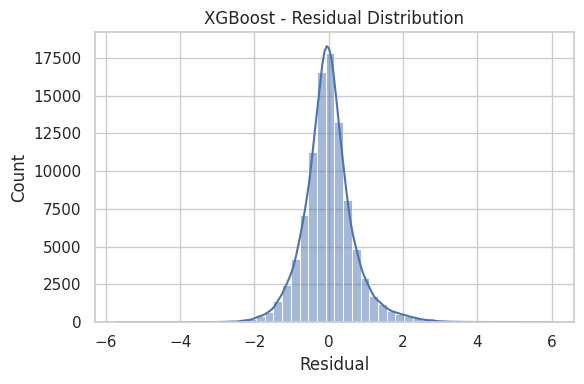

Residual distribution:  71%|███████▏  | 5/7 [00:04<00:01,  1.03it/s]

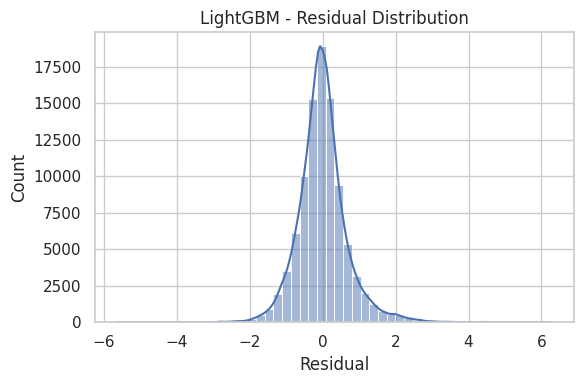

Residual distribution:  86%|████████▌ | 6/7 [00:06<00:01,  1.33s/it]

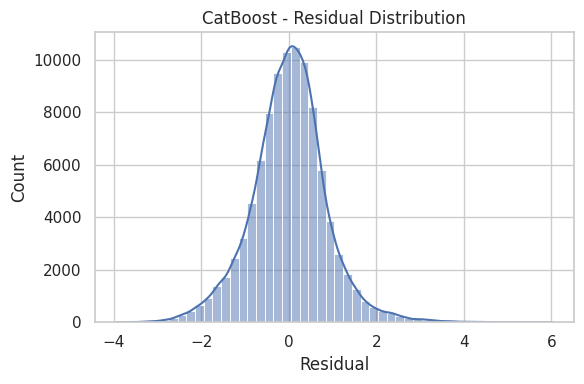

Residual distribution: 100%|██████████| 7/7 [00:07<00:00,  1.05s/it]


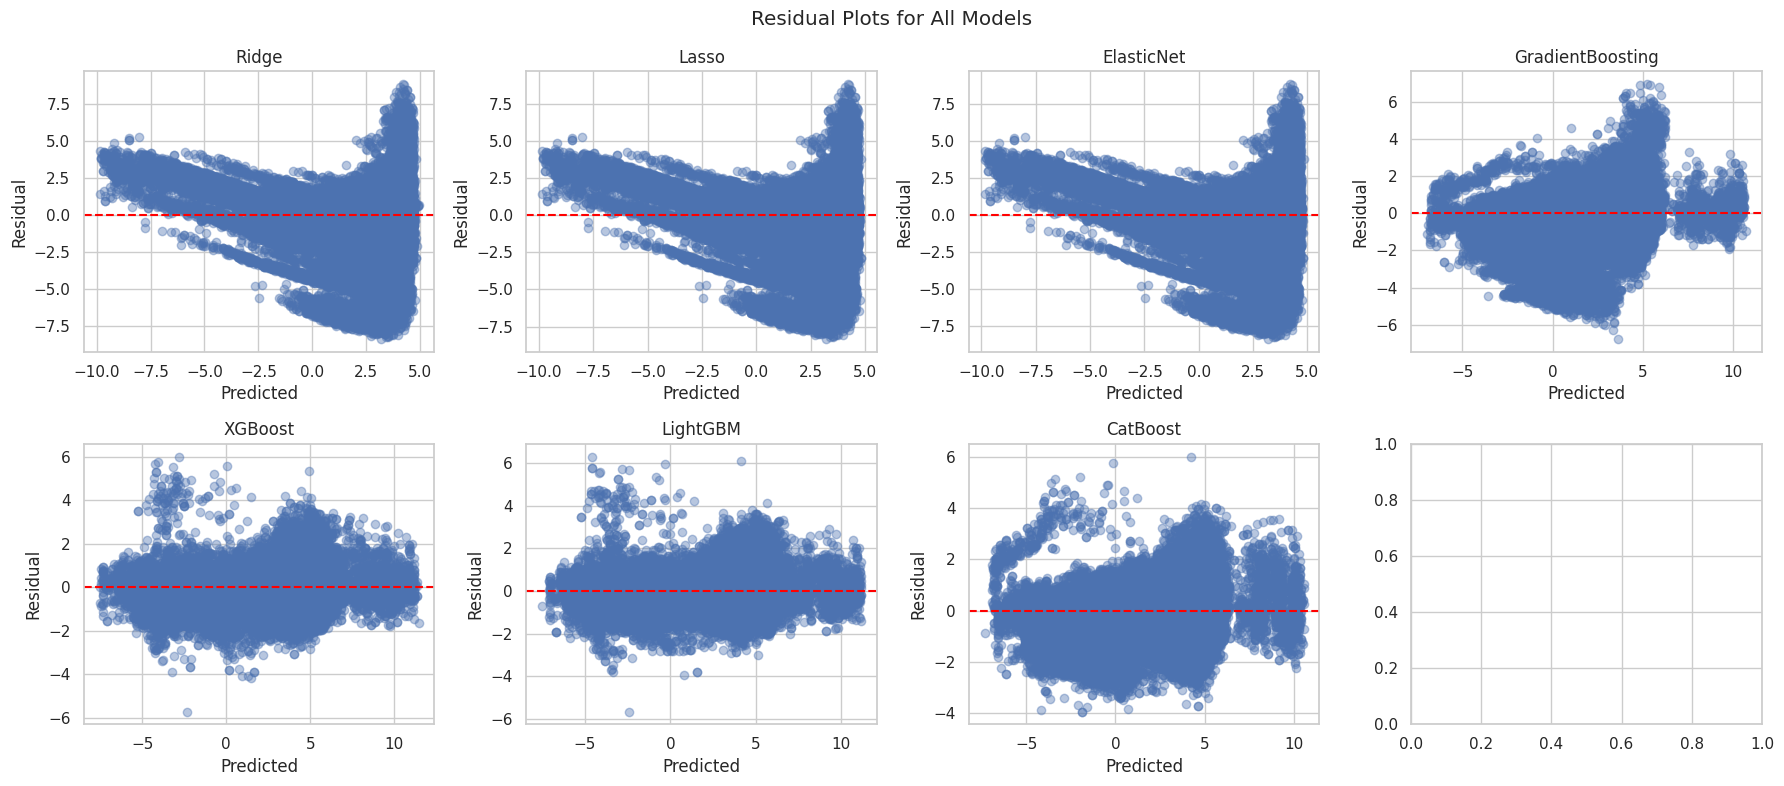

In [34]:
# Residual scatter plots
for name, model in tqdm(trained_models.items(), desc="Plotting residuals"):
    
    if name in ["Ridge", "Lasso", "ElasticNet"]:
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = model.predict(X_test)
    
    residuals = y_test - y_pred
    
    plt.figure(figsize=(6,5))
    sns.scatterplot(x=y_pred, y=residuals, alpha=0.4)
    
    plt.axhline(0, color="red", linestyle="--")
    plt.xlabel("Predicted LN_IC50")
    plt.ylabel("Residuals (True - Predicted)")
    plt.title(f"{name} - Residual Plot")
    
    plt.tight_layout()
    plt.show()

for name, model in tqdm(trained_models.items(), desc="Residual distribution"):
    
    if name in ["Ridge", "Lasso", "ElasticNet"]:
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = model.predict(X_test)
    
    residuals = y_test - y_pred
    
    plt.figure(figsize=(6,4))
    sns.histplot(residuals, bins=50, kde=True)
    plt.title(f"{name} - Residual Distribution")
    plt.xlabel("Residual")
    plt.tight_layout()
    plt.show()

fig, axes = plt.subplots(2, 4, figsize=(18,8))
axes = axes.flatten()

for ax, (name, model) in zip(axes, trained_models.items()):
    
    if name in ["Ridge", "Lasso", "ElasticNet"]:
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = model.predict(X_test)
    
    residuals = y_test - y_pred
    
    ax.scatter(y_pred, residuals, alpha=0.4)
    ax.axhline(0, color="red", linestyle="--")
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Residual")

plt.suptitle("Residual Plots for All Models")
plt.tight_layout()
plt.show()

- Residual plots allow us to verify whether prediction errors are randomly distributed around zero. Models such as LightGBM and XGBoost present tighter and more symmetric residual distributions, indicating better generalization. Linear models show higher dispersion and potential underfitting.

Prediction plots:   0%|          | 0/7 [00:00<?, ?it/s]

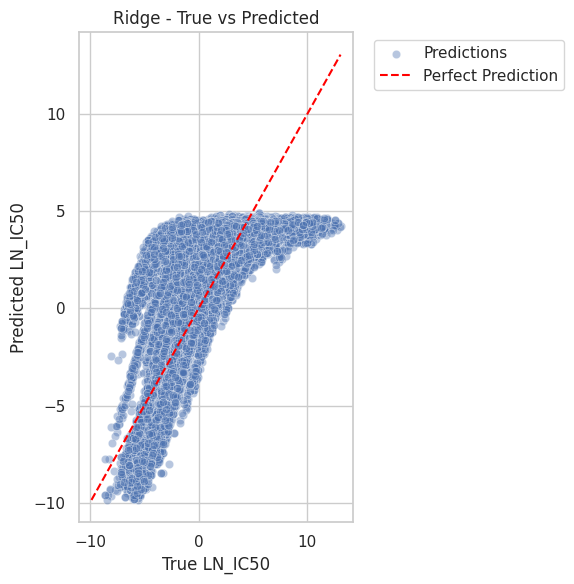

Prediction plots:  14%|█▍        | 1/7 [00:00<00:03,  1.99it/s]

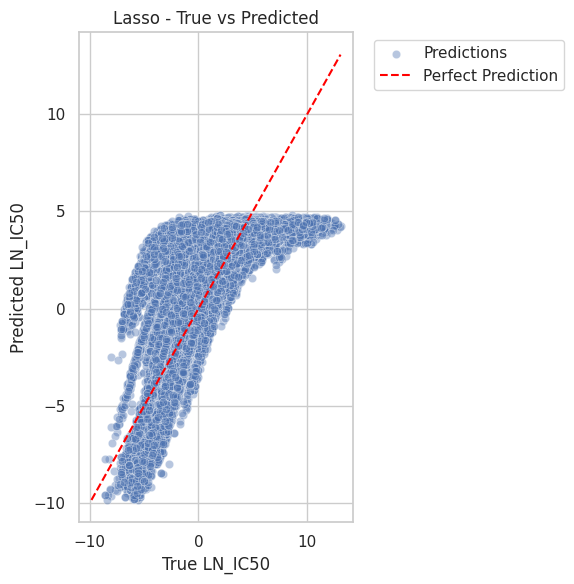

Prediction plots:  29%|██▊       | 2/7 [00:01<00:02,  2.00it/s]

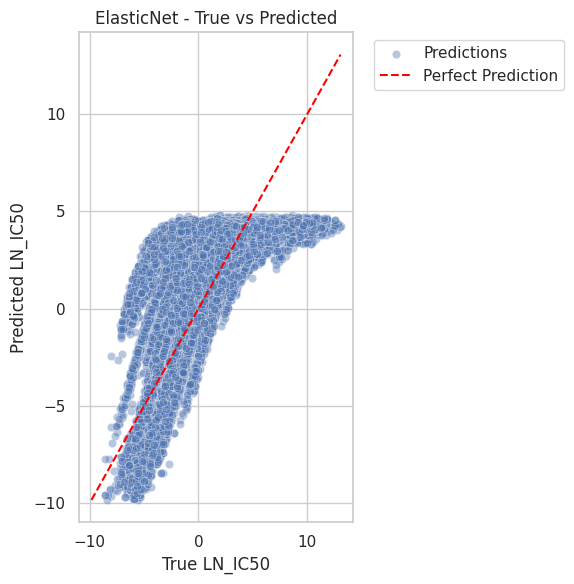

Prediction plots:  43%|████▎     | 3/7 [00:01<00:02,  1.95it/s]

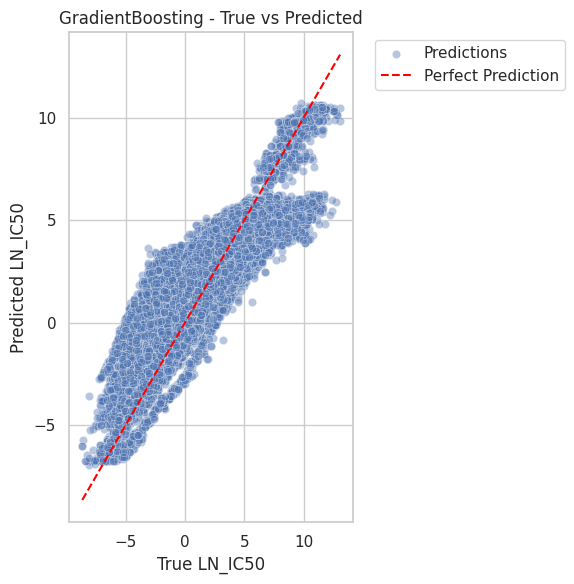

Prediction plots:  57%|█████▋    | 4/7 [00:02<00:01,  1.80it/s]

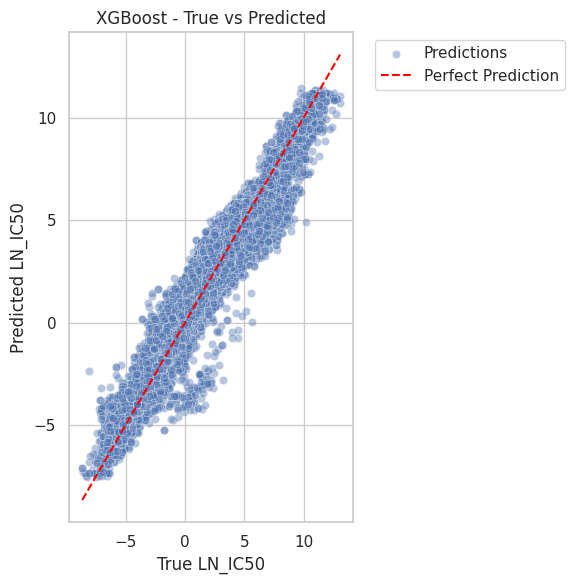

Prediction plots:  71%|███████▏  | 5/7 [00:03<00:01,  1.48it/s]

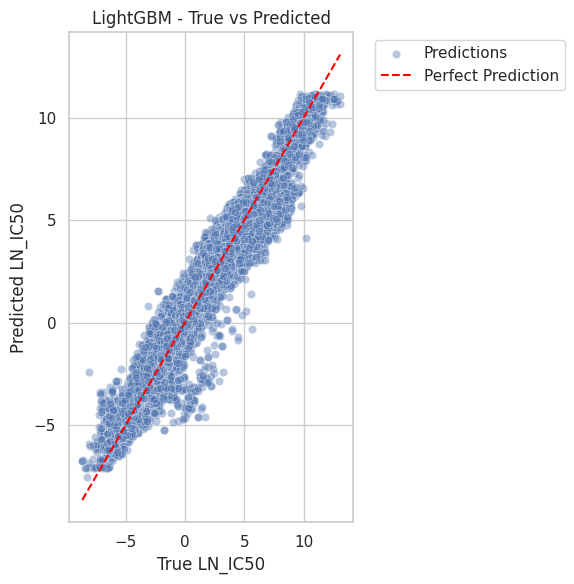

Prediction plots:  86%|████████▌ | 6/7 [00:04<00:01,  1.05s/it]

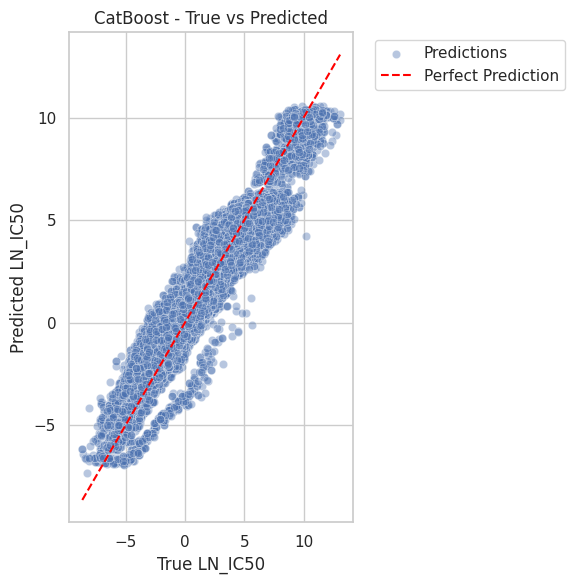

Prediction plots: 100%|██████████| 7/7 [00:05<00:00,  1.32it/s]


In [35]:
# Prediction scatter plots
for name, model in tqdm(trained_models.items(), desc="Prediction plots"):
    
    if name in ["Ridge", "Lasso", "ElasticNet"]:
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = model.predict(X_test)
    
    plt.figure(figsize=(6,6))
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.4, label="Predictions")
    
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    plt.plot(
        [min_val, max_val],
        [min_val, max_val],
        color="red",
        linestyle="--",
        label="Perfect Prediction"
    )
    
    plt.xlabel("True LN_IC50")
    plt.ylabel("Predicted LN_IC50")
    plt.title(f"{name} - True vs Predicted")
    
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    
    plt.tight_layout()
    plt.show()

In [36]:
save_path = r"C:\Users\rafae.RAFAEL_NOTEBOOK\Downloads\Genomics of Drug Sensitivity in Cancer (GDSC)\models\modelos_regressao_linear"

os.makedirs(save_path, exist_ok=True)

for name, model in tqdm(trained_models.items(), desc="Saving models"):
    file_path = os.path.join(save_path, f"{name}_regression_model.pkl")
    joblib.dump(model, file_path)
    print(f"Saved: {file_path}")

print("All regression models saved successfully.")

Saving models: 100%|██████████| 7/7 [00:00<00:00, 181.68it/s]

Saved: C:\Users\rafae.RAFAEL_NOTEBOOK\Downloads\Genomics of Drug Sensitivity in Cancer (GDSC)\models\modelos_regressao_linear/Ridge_regression_model.pkl
Saved: C:\Users\rafae.RAFAEL_NOTEBOOK\Downloads\Genomics of Drug Sensitivity in Cancer (GDSC)\models\modelos_regressao_linear/Lasso_regression_model.pkl
Saved: C:\Users\rafae.RAFAEL_NOTEBOOK\Downloads\Genomics of Drug Sensitivity in Cancer (GDSC)\models\modelos_regressao_linear/ElasticNet_regression_model.pkl
Saved: C:\Users\rafae.RAFAEL_NOTEBOOK\Downloads\Genomics of Drug Sensitivity in Cancer (GDSC)\models\modelos_regressao_linear/GradientBoosting_regression_model.pkl
Saved: C:\Users\rafae.RAFAEL_NOTEBOOK\Downloads\Genomics of Drug Sensitivity in Cancer (GDSC)\models\modelos_regressao_linear/XGBoost_regression_model.pkl
Saved: C:\Users\rafae.RAFAEL_NOTEBOOK\Downloads\Genomics of Drug Sensitivity in Cancer (GDSC)\models\modelos_regressao_linear/LightGBM_regression_model.pkl
Saved: C:\Users\rafae.RAFAEL_NOTEBOOK\Downloads\Genomics of D

In [37]:
# Evaluate regression models
results = []

for name, model in tqdm(trained_models.items(), desc="Evaluating models"):
    
    if name in ["Ridge", "Lasso", "ElasticNet"]:
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        "Model": name,
        "R2": r2,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse
    })

results_df = pd.DataFrame(results).sort_values("RMSE")
results_df

Evaluating models: 100%|██████████| 7/7 [00:02<00:00,  3.49it/s]


,Model,R2,MAE,MSE,RMSE
5,LightGBM,0.940648,0.483187,0.453742,0.673604
4,XGBoost,0.937455,0.495128,0.478150,0.691484
6,CatBoost,0.903785,0.645574,0.735555,0.857645
3,GradientBoosting,0.827477,0.826525,1.318932,1.148448
0,Ridge,0.585118,1.222900,3.171749,1.780940
2,ElasticNet,0.585086,1.222891,3.171996,1.781010
1,Lasso,0.585080,1.222895,3.172042,1.781023


In [38]:
from sklearn.preprocessing import LabelEncoder
import joblib

categorical_cols_for_web = [
    "TARGET",
    "TARGET_PATHWAY",
    "TCGA_DESC",
    "GDSC_TISSUE_DESCRIPTOR_2",
    "CANCER_TYPE_MATCHING_TCGA_LABEL",
    "SITE",
    "GDSC_TISSUE_DESCRIPTOR_1"
]

regression_encoders = {}

for col in categorical_cols_for_web:
    le = LabelEncoder()
    le.fit(df_fe[col].astype(str))
    regression_encoders[col] = le

print("Encoders created for:")
print(list(regression_encoders.keys()))

Encoders created for:
['TARGET', 'TARGET_PATHWAY', 'TCGA_DESC', 'GDSC_TISSUE_DESCRIPTOR_2', 'CANCER_TYPE_MATCHING_TCGA_LABEL', 'SITE', 'GDSC_TISSUE_DESCRIPTOR_1']


In [39]:
import os
import joblib
import shutil

save_dir = "/kaggle/working/regression_package"
os.makedirs(save_dir, exist_ok=True)

for name, model in trained_models.items():

    filename = (
        name.lower()
        .replace(" ", "_")
        + "_regression_model.pkl"
    )

    joblib.dump(
        model,
        os.path.join(save_dir, filename)
    )

joblib.dump(
    MODEL_FEATURES,
    os.path.join(
        save_dir,
        "regression_features.pkl"
    )
)

joblib.dump(
    regression_encoders,
    os.path.join(
        save_dir,
        "regression_label_encoders.pkl"
    )
)

results_df.to_csv(
    os.path.join(
        save_dir,
        "regression_results.csv"
    ),
    index=False
)

shutil.make_archive(
    "/kaggle/working/regression_package",
    "zip",
    save_dir
)

print("Done")
print("/kaggle/working/regression_package.zip")

Done
/kaggle/working/regression_package.zip


In [40]:
results_df.to_csv(
"/kaggle/working/regression_results.csv",
index=False
)

In [41]:
import shutil

shutil.make_archive(
"/kaggle/working/regression_package",
"zip",
"/kaggle/working/regression_package"
)

'/kaggle/working/regression_package.zip'